# Churn Full Analysis



### Task 1 : Data Cleaning & Preprocessing


### Task 2 : Exploratory Data Analysis (EDA)


### Task 3 : Basic Data Visualization


In [1]:
# Standard Library
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print('All libraries imported successfully')

All libraries imported successfully


In [2]:
# Load both files
df_train = pd.read_csv('churn-bigml-80.csv')
df_test  = pd.read_csv('churn-bigml-20.csv')

# Tag each row so we can split again after cleaning
df_train['_split'] = 'train'
df_test['_split']  = 'test'

# Merge into one DataFrame
df = pd.concat([df_train, df_test], ignore_index=True)

print(f'Training rows  : {len(df_train):,}')
print(f'Test rows      : {len(df_test):,}')
print(f'Combined rows  : {len(df):,}')
print(f'Columns        : {df.shape[1]}')

Training rows  : 2,666
Test rows      : 667
Combined rows  : 3,333
Columns        : 21


In [3]:
# First look at the data
df.head(10)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,_split
0,KS,128,415,No,Yes,25,265.10,110,45.07,197.40,99,16.78,244.70,91,11.01,10.00,3,2.70,1,False,train
1,OH,107,415,No,Yes,26,161.60,123,27.47,195.50,103,16.62,254.40,103,11.45,13.70,3,3.70,1,False,train
2,NJ,137,415,No,No,0,243.40,114,41.38,121.20,110,10.30,162.60,104,7.32,12.20,5,3.29,0,False,train
3,OH,84,408,Yes,No,0,299.40,71,50.90,61.90,88,5.26,196.90,89,8.86,6.60,7,1.78,2,False,train
4,OK,75,415,Yes,No,0,166.70,113,28.34,148.30,122,12.61,186.90,121,8.41,10.10,3,2.73,3,False,train
5,AL,118,510,Yes,No,0,223.40,98,37.98,220.60,101,18.75,203.90,118,9.18,6.30,6,1.70,0,False,train
6,MA,121,510,No,Yes,24,218.20,88,37.09,348.50,108,29.62,212.60,118,9.57,7.50,7,2.03,3,False,train
7,MO,147,415,Yes,No,0,157.00,79,26.69,103.10,94,8.76,211.80,96,9.53,7.10,6,1.92,0,False,train
8,WV,141,415,Yes,Yes,37,258.60,84,43.96,222.00,111,18.87,326.40,97,14.69,11.20,5,3.02,0,False,train
9,RI,74,415,No,No,0,187.70,127,31.91,163.40,148,13.89,196.00,94,8.82,9.10,5,2.46,0,False,train


In [4]:
# Last rows
df.tail(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,_split
3328,WI,114,415,No,Yes,26,137.10,88,23.31,155.70,125,13.23,247.60,94,11.14,11.50,7,3.11,2,False,test
3329,AL,106,408,No,Yes,29,83.60,131,14.21,203.90,131,17.33,229.50,73,10.33,8.10,3,2.19,1,False,test
3330,VT,60,415,No,No,0,193.90,118,32.96,85.00,110,7.23,210.10,134,9.45,13.20,8,3.56,3,False,test
3331,WV,159,415,No,No,0,169.80,114,28.87,197.70,105,16.80,193.70,82,8.72,11.60,4,3.13,1,False,test
3332,CT,184,510,Yes,No,0,213.80,105,36.35,159.60,84,13.57,139.20,137,6.26,5.00,10,1.35,2,False,test


##  Initial Exploration



In [5]:
# Shape & column overview
print('='*60)
print(f'  DATASET SHAPE: {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
print('='*60)
print()
print(df.info())

  DATASET SHAPE: 3,333 rows  ×  21 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 

In [6]:
#  Statistical summary : numeric columns
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','max'])

,count,mean,std,min,25%,50%,75%,max
Account length,3333.000000,101.064806,39.822106,1.000000,74.000000,101.000000,127.000000,243.000000
Area code,3333.000000,437.182418,42.371290,408.000000,408.000000,415.000000,510.000000,510.000000
Number vmail messages,3333.000000,8.099010,13.688365,0.000000,0.000000,0.000000,20.000000,51.000000
Total day minutes,3333.000000,179.775098,54.467389,0.000000,143.700000,179.400000,216.400000,350.800000
Total day calls,3333.000000,100.435644,20.069084,0.000000,87.000000,101.000000,114.000000,165.000000
Total day charge,3333.000000,30.562307,9.259435,0.000000,24.430000,30.500000,36.790000,59.640000
Total eve minutes,3333.000000,200.980348,50.713844,0.000000,166.600000,201.400000,235.300000,363.700000
Total eve calls,3333.000000,100.114311,19.922625,0.000000,87.000000,100.000000,114.000000,170.000000
Total eve charge,3333.000000,17.083540,4.310668,0.000000,14.160000,17.120000,20.000000,30.910000
Total night minutes,3333.000000,200.872037,50.573847,23.200000,167.000000,201.200000,235.300000,395.000000


In [7]:
# Statistical summary : categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)
df[cat_cols].describe()

Categorical columns: ['State', 'International plan', 'Voice mail plan', '_split']


,State,International plan,Voice mail plan,_split
count,3333,3333,3333,3333
unique,51,2,2,2
top,WV,No,No,train
freq,106,3010,2411,2666


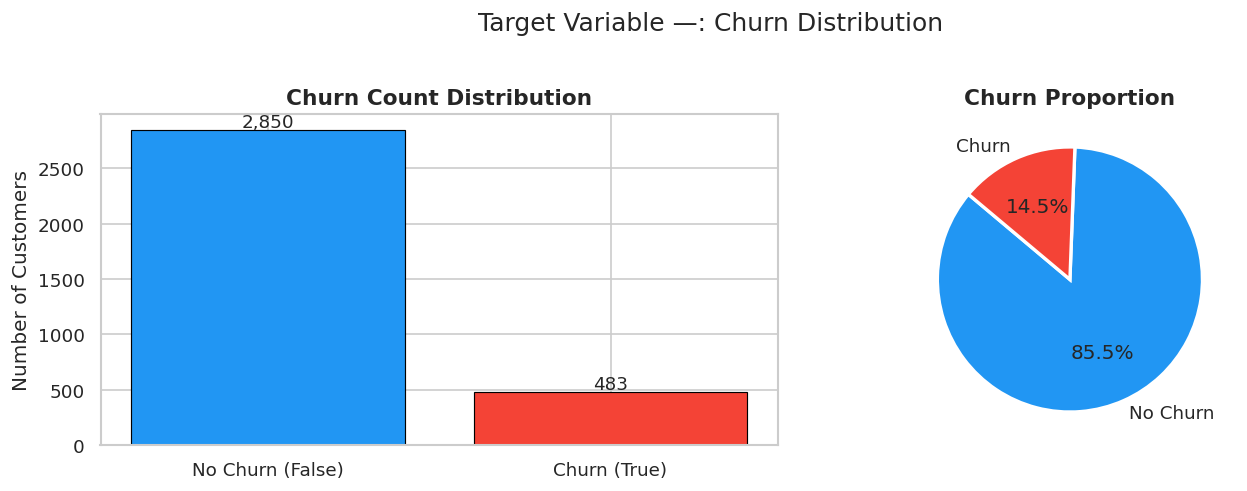


Churn rate: 14.5%  |  Retention rate: 85.5%


In [8]:
# Churn distribution (target variable)
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Churn (False)', 'Churn (True)'],
            churn_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.7)
axes[0].set_title('Churn Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(churn_pct.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2196F3','#F44336'],
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable —: Churn Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('01_churn_distribution.png', bbox_inches='tight')
plt.show()
print(f'\nChurn rate: {churn_pct[True]:.1f}%  |  Retention rate: {churn_pct[False]:.1f}%')


## Missing Values : Detection and Handling


In [9]:
# Count and percentage of missing values
missing = pd.DataFrame({
    'Missing Count'   : df.isnull().sum(),
    'Missing %'       : (df.isnull().sum() / len(df) * 100).round(2),
    'Data Type'       : df.dtypes
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('\n Columns with Missing Values:')
print('='*50)
print(missing.to_string())
print(f'\nTotal missing cells : {df.isnull().sum().sum():,}')
print(f'Overall missing %   : {df.isnull().sum().sum() / df.size * 100:.2f}%')


 Columns with Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %, Data Type]
Index: []

Total missing cells : 0
Overall missing %   : 0.00%


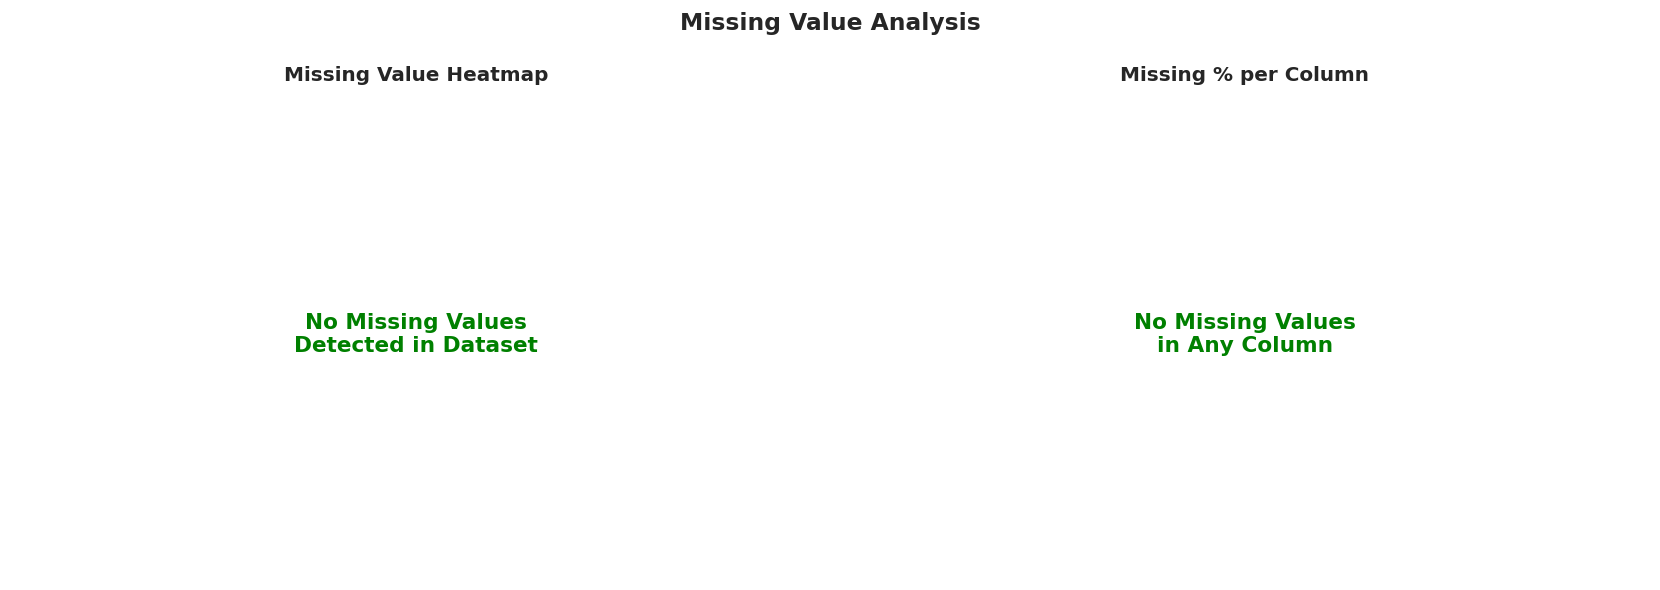

 Missing value analysis complete : no nulls found in this dataset


In [10]:
# Visualise missing values heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of nulls  guard against no-NA case
cols_with_na = df.columns[df.isnull().any()].tolist()
if cols_with_na:
    sns.heatmap(df[cols_with_na].isnull(),
                yticklabels=False, cbar=False,
                cmap='viridis', ax=axes[0])
    axes[0].set_title('Missing Value Heatmap\n(yellow = missing)', fontsize=12, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values\nDetected in Dataset',
                 ha='center', va='center', fontsize=13, fontweight='bold',
                 color='green', transform=axes[0].transAxes)
    axes[0].set_title('Missing Value Heatmap', fontsize=12, fontweight='bold')
    axes[0].axis('off')
axes[0].set_xlabel('Columns')
axes[0].set_ylabel('Rows')

# Bar chart of missing %
if not missing.empty:
    axes[1].barh(missing.index, missing['Missing %'],
                 color='#FF7043', edgecolor='black', linewidth=0.5)
    axes[1].set_xlabel('Missing Percentage (%)')
    axes[1].set_title('Missing % per Column', fontsize=12, fontweight='bold')
    for i, v in enumerate(missing['Missing %']):
        axes[1].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=10)
    axes[1].axvline(x=5, color='red', linestyle='--', linewidth=1, label='5% threshold')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No Missing Values\nin Any Column',
                 ha='center', va='center', fontsize=13, fontweight='bold',
                 color='green', transform=axes[1].transAxes)
    axes[1].set_title('Missing % per Column', fontsize=12, fontweight='bold')
    axes[1].axis('off')

plt.suptitle('Missing Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_missing_values.png', bbox_inches='tight')
plt.show()
print(' Missing value analysis complete : no nulls found in this dataset')


In [11]:
# Imputation Strategy
print('Applying Imputation Strategy')
print('─'*50)

imputation_log = []

for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing == 0:
        continue

    pct = n_missing / len(df) * 100

    # Decision: drop column if > 50% missing (none expected)
    if pct > 50:
        df.drop(columns=[col], inplace=True)
        strategy = f'DROPPED (>{pct:.1f}% missing)'

    # Numeric → median imputation
    elif df[col].dtype in ['float64', 'int64']:
        fill_val = df[col].median()
        df[col].fillna(fill_val, inplace=True)
        strategy = f'Median imputation  →  filled with {fill_val:.2f}'

    # Categorical → mode imputation
    else:
        fill_val = df[col].mode()[0]
        df[col].fillna(fill_val, inplace=True)
        strategy = f'Mode imputation    →  filled with "{fill_val}"'

    imputation_log.append({'Column': col, 'Missing (before)': n_missing,
                           'Missing %': f'{pct:.2f}%', 'Strategy': strategy})

imp_df = pd.DataFrame(imputation_log)

if imp_df.empty:
    print('No missing values found : imputation not required.')
else:
    print(imp_df.to_string(index=False))

# Verify
remaining_na = df.isnull().sum().sum()
print(f'\n Missing values remaining after imputation: {remaining_na}')


Applying Imputation Strategy
──────────────────────────────────────────────────
No missing values found : imputation not required.

 Missing values remaining after imputation: 0



## Duplicate Rows : Detection and  Removal


In [12]:
# Detect duplicates
n_before = len(df)
n_dupes  = df.duplicated().sum()

print('='*50)
print(f'  Total rows (before dedup) : {n_before:,}')
print(f'  Duplicate rows found      : {n_dupes:,}')
print(f'  Duplication rate          : {n_dupes/n_before*100:.2f}%')
print('='*50)

# Preview duplicate rows
if n_dupes > 0:
    print(f'\n First 5 duplicate rows (preview):')
    print(df[df.duplicated(keep=False)].head(10).to_string())

  Total rows (before dedup) : 3,333
  Duplicate rows found      : 0
  Duplication rate          : 0.00%


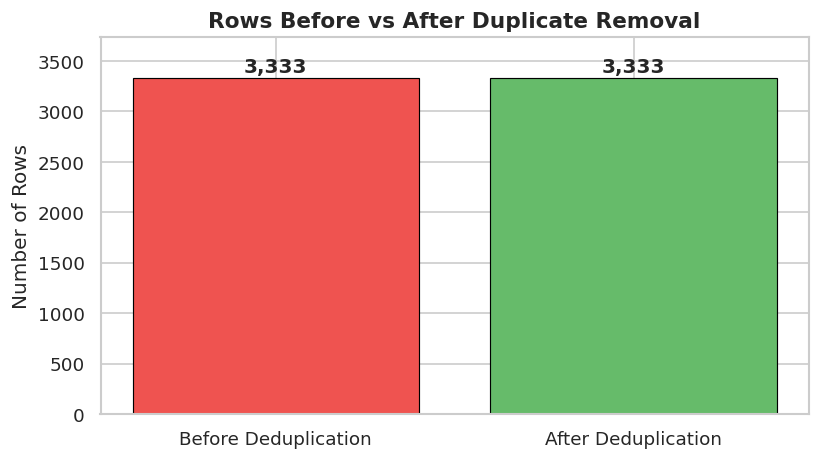

Removed 0 duplicate rows
   Rows remaining: 3,333


In [13]:
# Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

n_after = len(df)

# Visual summary
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Before Deduplication', 'After Deduplication'],
               [n_before, n_after],
               color=['#EF5350', '#66BB6A'], edgecolor='black', linewidth=0.7)
ax.set_ylabel('Number of Rows')
ax.set_title('Rows Before vs After Duplicate Removal', fontsize=13, fontweight='bold')
for bar, val in zip(bars, [n_before, n_after]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(n_before, n_after) * 1.12)
plt.tight_layout()
plt.savefig('03_deduplication.png', bbox_inches='tight')
plt.show()

print(f'Removed {n_before - n_after:,} duplicate rows')
print(f'   Rows remaining: {n_after:,}')


##  Inconsistent Data Formats : Standardization


In [14]:
# Audit categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
# Remove helper columns from audit
audit_cols = [c for c in cat_cols if c not in ['_split']]

print('Unique Values in Categorical Columns:')
print('='*60)
for col in audit_cols:
    uniques = df[col].unique()
    print(f'\n  [{col}]  ({len(uniques)} unique values)')
    print(f'  → {sorted([str(u) for u in uniques])}')

Unique Values in Categorical Columns:

  [State]  (51 unique values)
  → ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']

  [International plan]  (2 unique values)
  → ['No', 'Yes']

  [Voice mail plan]  (2 unique values)
  → ['No', 'Yes']


In [15]:
# Standardize string columns
print('Standardizing categorical columns...')
print('─'*50)

binary_map = {'yes': 'Yes', 'YES': 'Yes', 'no': 'No', 'NO': 'No'}

for col in audit_cols:
    before = df[col].unique().tolist()

    # Strip whitespace
    df[col] = df[col].astype(str).str.strip()

    # Title-case for Yes/No binary columns
    if set(df[col].str.lower().unique()) <= {'yes', 'no', 'nan'}:
        df[col] = df[col].str.strip().replace(binary_map)

    # State codes — upper case
    elif col == 'State':
        df[col] = df[col].str.upper()

    after = df[col].unique().tolist()
    if sorted([str(b) for b in before]) != sorted([str(a) for a in after]):
        print(f'  [{col}]')
        print(f'    Before → {sorted([str(b) for b in before])}')
        print(f'    After  → {sorted([str(a) for a in after])}')

print('\n Categorical columns standardized!')

Standardizing categorical columns...
──────────────────────────────────────────────────

 Categorical columns standardized!


In [16]:
# Validate after standardization
print('Post-standardization value counts:')
for col in ['International plan', 'Voice mail plan']:
    print(f'\n  [{col}]')
    print(df[col].value_counts().to_string())

Post-standardization value counts:

  [International plan]
International plan
No     3010
Yes     323

  [Voice mail plan]
Voice mail plan
No     2411
Yes     922


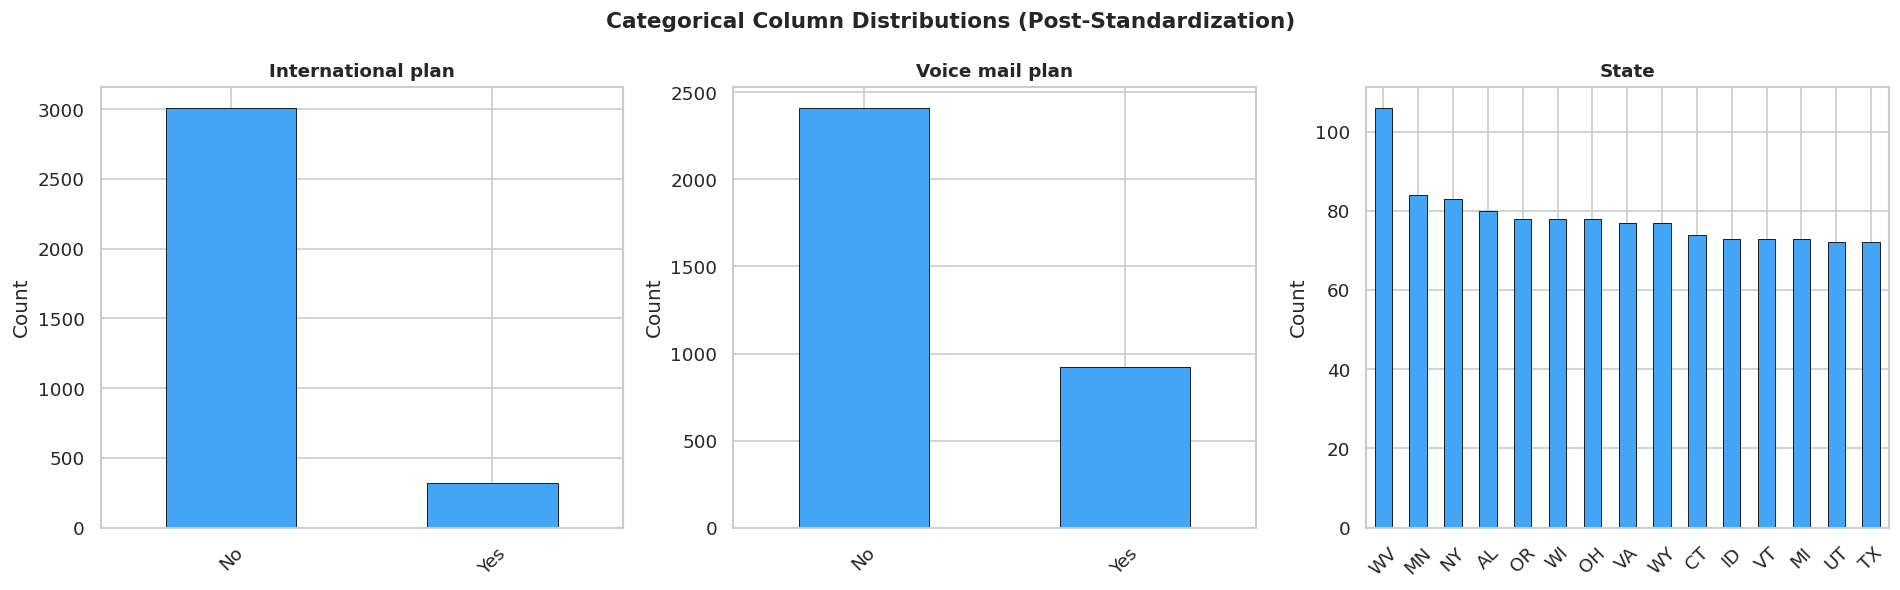

In [17]:
# Visualise categorical distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['International plan', 'Voice mail plan', 'State']):
    vc = df[col].value_counts().head(15)  # top 15 for State
    vc.plot(kind='bar', ax=ax, color='#42A5F5', edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Column Distributions (Post-Standardization)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_categorical_distributions.png', bbox_inches='tight')
plt.show()


## Outlier Detection and Treatment


In [18]:
# IQR-based outlier detection
num_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
# Exclude non-feature numerics
exclude = ['Area code']
num_cols = [c for c in num_cols if c not in exclude]

outlier_summary = []
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        outlier_summary.append({
            'Column'        : col,
            'Q1'            : round(Q1, 2),
            'Q3'            : round(Q3, 2),
            'IQR'           : round(IQR, 2),
            'Lower Fence'   : round(lower, 2),
            'Upper Fence'   : round(upper, 2),
            'Outlier Count' : n_out,
            'Outlier %'     : round(n_out / len(df) * 100, 2)
        })

out_df = pd.DataFrame(outlier_summary)
print(' Outlier Detection Report (IQR Method):')
print(out_df.to_string(index=False))

 Outlier Detection Report (IQR Method):
                Column     Q1     Q3   IQR  Lower Fence  Upper Fence  Outlier Count  Outlier %
        Account length  74.00 127.00 53.00        -5.50       206.50             18       0.54
 Number vmail messages   0.00  20.00 20.00       -30.00        50.00              1       0.03
     Total day minutes 143.70 216.40 72.70        34.65       325.45             25       0.75
       Total day calls  87.00 114.00 27.00        46.50       154.50             23       0.69
      Total day charge  24.43  36.79 12.36         5.89        55.33             25       0.75
     Total eve minutes 166.60 235.30 68.70        63.55       338.35             24       0.72
       Total eve calls  87.00 114.00 27.00        46.50       154.50             20       0.60
      Total eve charge  14.16  20.00  5.84         5.40        28.76             24       0.72
   Total night minutes 167.00 235.30 68.30        64.55       337.75             30       0.90
     Total

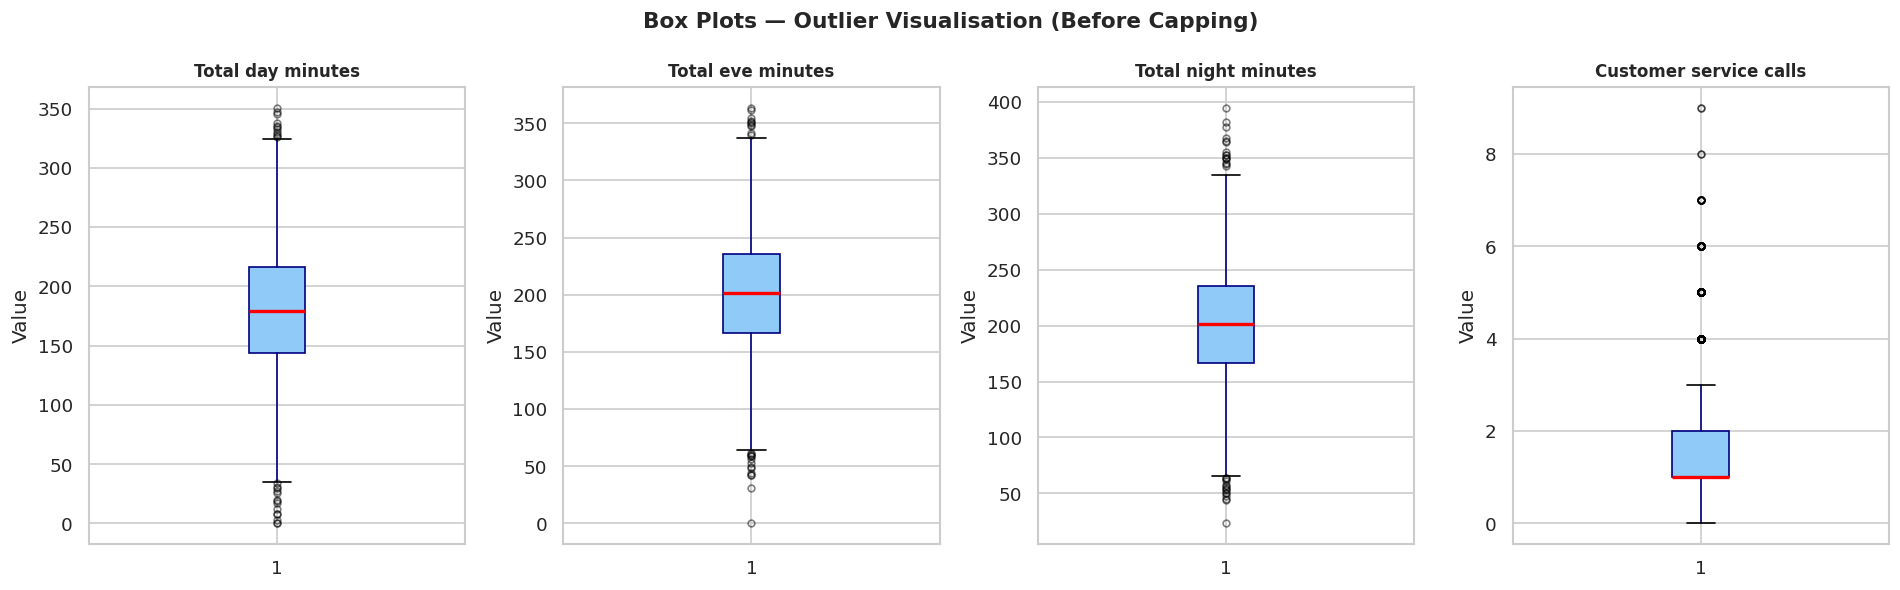

In [19]:
# Box plots before capping
key_cols = ['Total day minutes', 'Total eve minutes',
            'Total night minutes', 'Customer service calls']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, key_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#90CAF9', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='navy'),
               flierprops=dict(marker='o', color='red', markersize=4, alpha=0.5))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Box Plots — Outlier Visualisation (Before Capping)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_boxplots_before.png', bbox_inches='tight')
plt.show()

In [20]:
# Winsorisation (IQR capping)
print('Applying IQR Winsorisation (capping outliers)...')
print('─'*55)

for col in num_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_low  = (df[col] < lower).sum()
    n_high = (df[col] > upper).sum()

    if n_low > 0 or n_high > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'  [{col}]  clipped {n_low} low + {n_high} high → [{lower:.2f}, {upper:.2f}]')

print('\n Winsorisation complete')

Applying IQR Winsorisation (capping outliers)...
───────────────────────────────────────────────────────
  [Account length]  clipped 0 low + 18 high → [-5.50, 206.50]
  [Number vmail messages]  clipped 0 low + 1 high → [-30.00, 50.00]
  [Total day minutes]  clipped 14 low + 11 high → [34.65, 325.45]
  [Total day calls]  clipped 15 low + 8 high → [46.50, 154.50]
  [Total day charge]  clipped 14 low + 11 high → [5.89, 55.33]
  [Total eve minutes]  clipped 14 low + 10 high → [63.55, 338.35]
  [Total eve calls]  clipped 11 low + 9 high → [46.50, 154.50]
  [Total eve charge]  clipped 14 low + 10 high → [5.40, 28.76]
  [Total night minutes]  clipped 15 low + 15 high → [64.55, 337.75]
  [Total night calls]  clipped 7 low + 15 high → [48.00, 152.00]
  [Total night charge]  clipped 15 low + 15 high → [2.91, 15.20]
  [Total intl minutes]  clipped 32 low + 14 high → [3.10, 17.50]
  [Total intl calls]  clipped 0 low + 78 high → [-1.50, 10.50]
  [Total intl charge]  clipped 32 low + 17 high → [0.84

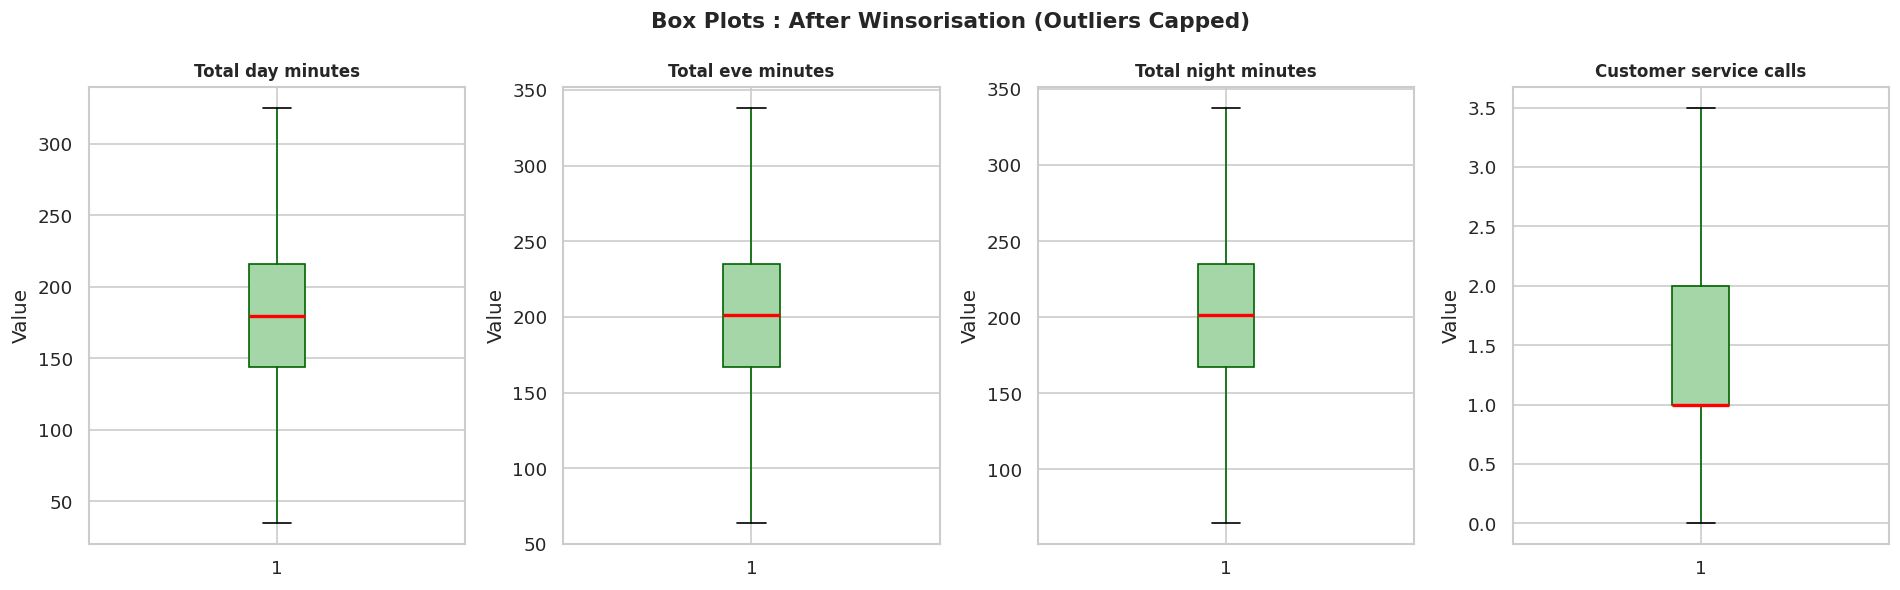

In [21]:
#  Box plots after capping
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, key_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#A5D6A7', color='darkgreen'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='darkgreen'),
               flierprops=dict(marker='o', color='orange', markersize=4, alpha=0.5))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Box Plots : After Winsorisation (Outliers Capped)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_boxplots_after.png', bbox_inches='tight')
plt.show()


## Data Type Validation


In [22]:
# Enforce correct data types
print(' Enforcing data types   ')

# Churn → boolean
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'True': True, 'False': False, True: True, False: False})

# Area code → category (it's a nominal code, not a number)
df['Area code']  = df['Area code'].astype('category')

# Binary Yes/No → category
df['International plan'] = df['International plan'].astype('category')
df['Voice mail plan']    = df['Voice mail plan'].astype('category')
df['State']              = df['State'].astype('category')

# Integer columns
int_cols = ['Account length','Number vmail messages',
            'Total day calls','Total eve calls',
            'Total night calls','Total intl calls','Customer service calls']
for col in int_cols:
    df[col] = df[col].astype(int)

print('\n Final Data Types:')
print(df.dtypes.to_string())

 Enforcing data types   

 Final Data Types:
State                     category
Account length               int64
Area code                 category
International plan        category
Voice mail plan           category
Number vmail messages        int64
Total day minutes          float64
Total day calls              int64
Total day charge           float64
Total eve minutes          float64
Total eve calls              int64
Total eve charge           float64
Total night minutes        float64
Total night calls            int64
Total night charge         float64
Total intl minutes         float64
Total intl calls             int64
Total intl charge          float64
Customer service calls       int64
Churn                         bool
_split                      object


In [23]:
# Memory usage comparison
mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f'Memory usage after optimisation: {mem_after:.2f} MB')
print(f'\nColumn dtypes summary:')
print(df.dtypes.value_counts().to_string())

Memory usage after optimisation: 0.57 MB

Column dtypes summary:
float64     8
int64       7
category    2
category    1
category    1
bool        1
object      1



## Final Clean Dataset



In [24]:
# Cleaning Summary Dashboard
print('='*65)
print('DATA CLEANING SUMMARY REPORT')
print('='*65)

missing_imputed = sum(imp_df['Missing (before)'].tolist()) if not imp_df.empty else 0
outliers_capped = int(out_df['Outlier Count'].sum()) if not out_df.empty else 0

summary_data = {
    'Metric' : ['Original Rows', 'After Deduplication',
                'Final Rows', 'Columns',
                'Missing Values Imputed', 'Outliers Capped',
                'Categorical Columns Standardized'],
    'Value'  : [f'{n_before:,}', f'{n_after:,}',
                f'{len(df):,}', f'{df.shape[1]}',
                f'{missing_imputed:,}',
                f'{outliers_capped:,}',
                f'{len([c for c in audit_cols if c in ["International plan","Voice mail plan"]])}']
}
summary = pd.DataFrame(summary_data)
print(summary.to_string(index=False))
print('='*65)


DATA CLEANING SUMMARY REPORT
                          Metric Value
                   Original Rows 3,333
             After Deduplication 3,333
                      Final Rows 3,333
                         Columns    21
          Missing Values Imputed     0
                 Outliers Capped   682
Categorical Columns Standardized     2


In [25]:
#  Final overview
print('Clean dataset first 5 rows:')
df.drop(columns=['_split'], errors='ignore').head()

Clean dataset first 5 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.10,110,45.07,197.40,99,16.78,244.70,91,11.01,10.00,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.60,123,27.47,195.50,103,16.62,254.40,103,11.45,13.70,3,3.70,1,False
2,NJ,137,415,No,No,0,243.40,114,41.38,121.20,110,10.30,162.60,104,7.32,12.20,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.40,71,50.90,63.55,88,5.40,196.90,89,8.86,6.60,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.70,113,28.34,148.30,122,12.61,186.90,121,8.41,10.10,3,2.73,3,False


In [26]:
# Verify zero missing values
assert df.isnull().sum().sum() == 0, ' Still has missing values!'
# Verify zero duplicates
assert df.duplicated().sum() == 0,   ' Still has duplicates!'

print(' All checks passed — dataset is clean!')
print(f'   Shape: {df.shape}')
print(f'   Churn rate: {df["Churn"].mean()*100:.1f}%')

 All checks passed — dataset is clean!
   Shape: (3333, 21)
   Churn rate: 14.5%


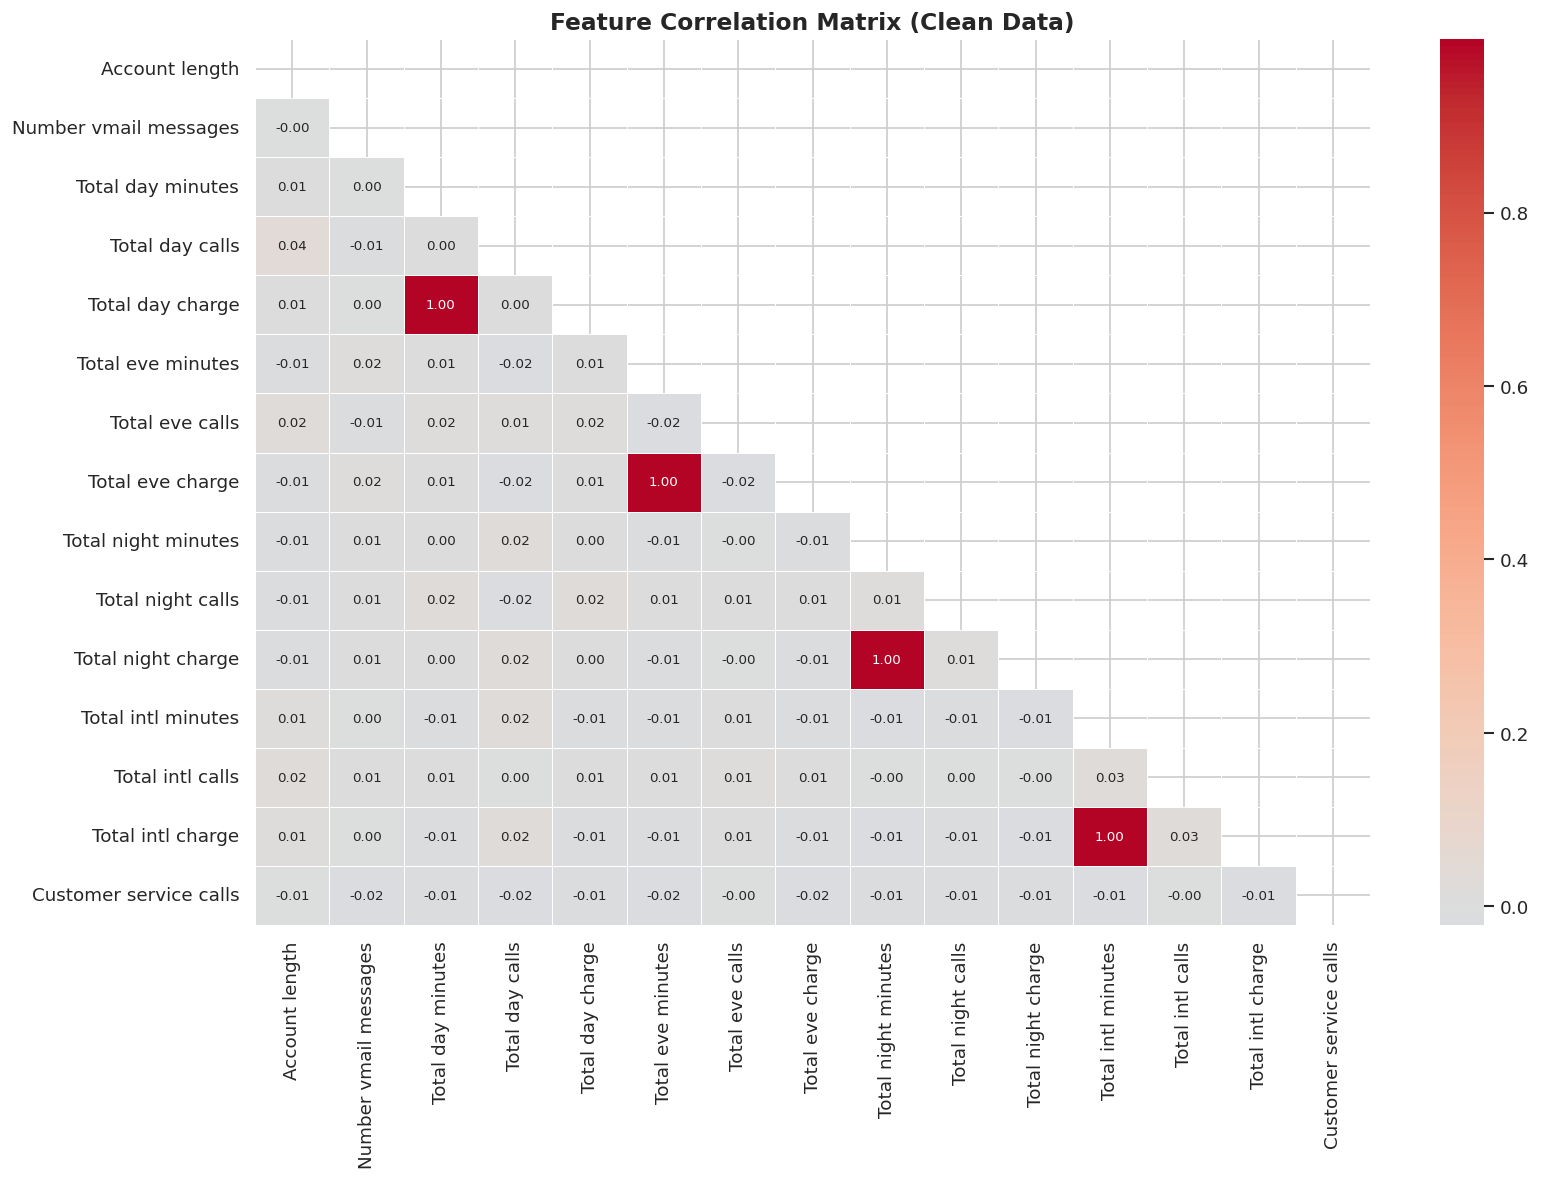

In [27]:
# Correlation heatmap of numeric features
num_df = df.select_dtypes(include=['float64','int64'])

fig, ax = plt.subplots(figsize=(14, 10))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (Clean Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', bbox_inches='tight')
plt.show()


## Save Cleaned Data



In [28]:
# Split back and drop helper column
df_train_clean = df[df['_split'] == 'train'].drop(columns=['_split']).reset_index(drop=True)
df_test_clean  = df[df['_split'] == 'test' ].drop(columns=['_split']).reset_index(drop=True)

# Save
df_train_clean.to_csv('churn_train_clean.csv', index=False)
df_test_clean.to_csv( 'churn_test_clean.csv',  index=False)

# Also save full clean dataset
df_full_clean = df.drop(columns=['_split'])
df_full_clean.to_csv('churn_full_clean.csv', index=False)

print(' Saved clean datasets:')
print(f'   churn_train_clean.csv → {df_train_clean.shape}')
print(f'   churn_test_clean.csv  → {df_test_clean.shape}')
print(f'   churn_full_clean.csv  → {df_full_clean.shape}')

 Saved clean datasets:
   churn_train_clean.csv → (2666, 20)
   churn_test_clean.csv  → (667, 20)
   churn_full_clean.csv  → (3333, 20)


In [29]:
#  Final preview of clean training data
print(' Clean Training Data : Statistical Summary:')
df_train_clean.describe().T.style.background_gradient(cmap='Greens', subset=['mean','std'])

 Clean Training Data : Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Account length,2666.000000,100.560390,39.388462,1.000000,73.000000,100.000000,127.000000,206.000000
Number vmail messages,2666.000000,8.021755,13.612277,0.000000,0.000000,0.000000,19.000000,50.000000
Total day minutes,2666.000000,179.536178,53.841588,34.650000,143.400000,179.950000,215.900000,325.450000
Total day calls,2666.000000,100.348462,19.794207,46.000000,87.000000,101.000000,114.000000,154.000000
Total day charge,2666.000000,30.521680,9.153054,5.890000,24.380000,30.590000,36.700000,55.330000
Total eve minutes,2666.000000,200.432821,50.639025,63.550000,165.300000,200.900000,235.100000,338.350000
Total eve calls,2666.000000,100.050638,19.997675,46.000000,87.000000,100.000000,114.000000,154.000000
Total eve charge,2666.000000,17.037033,4.304326,5.400000,14.050000,17.080000,19.980000,28.760000
Total night minutes,2666.000000,201.115979,50.320388,64.550000,166.925000,201.150000,236.475000,337.750000
Total night calls,2666.000000,100.102026,19.298896,48.000000,87.000000,100.000000,113.000000,152.000000



# Task 2: Exploratory Data Analysis (EDA)


In [30]:
#  Load clean data (use the saved clean file)
df_eda = pd.read_csv('churn_train_clean.csv')

print('='*65)
print('  CLEAN TRAINING DATASET : QUICK PROFILE')
print('='*65)
print(f'  Rows    : {df_eda.shape[0]:,}')
print(f'  Columns : {df_eda.shape[1]}')
print(f'  Churn   : {df_eda["Churn"].sum():,} ({df_eda["Churn"].mean()*100:.1f}%)')
print('='*65)
df_eda.head()

  CLEAN TRAINING DATASET : QUICK PROFILE
  Rows    : 2,666
  Columns : 20
  Churn   : 388 (14.6%)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.10,110,45.07,197.40,99,16.78,244.70,91,11.01,10.00,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.60,123,27.47,195.50,103,16.62,254.40,103,11.45,13.70,3,3.70,1,False
2,NJ,137,415,No,No,0,243.40,114,41.38,121.20,110,10.30,162.60,104,7.32,12.20,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.40,71,50.90,63.55,88,5.40,196.90,89,8.86,6.60,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.70,113,28.34,148.30,122,12.61,186.90,121,8.41,10.10,3,2.73,3,False


In [31]:
#  Mean, Median, Mode, Std for all numeric cols
num_cols_eda = df_eda.select_dtypes(include=['float64','int64','Int64']).columns.tolist()

stats = pd.DataFrame({
    'Mean'   : df_eda[num_cols_eda].mean().round(4),
    'Median' : df_eda[num_cols_eda].median().round(4),
    'Mode'   : df_eda[num_cols_eda].mode().iloc[0].round(4),
    'Std Dev': df_eda[num_cols_eda].std().round(4),
    'Min'    : df_eda[num_cols_eda].min().round(4),
    'Max'    : df_eda[num_cols_eda].max().round(4),
    'Skewness'  : df_eda[num_cols_eda].skew().round(4),
    'Kurtosis'  : df_eda[num_cols_eda].kurt().round(4),
})

print(' Summary Statistics : Numeric Features:')
stats.style.background_gradient(cmap='Blues', subset=['Mean','Std Dev']) \
           .format('{:.4f}')

 Summary Statistics : Numeric Features:


,Mean,Median,Mode,Std Dev,Min,Max,Skewness,Kurtosis
Account length,100.5604,100.0000,93.0000,39.3885,1.0000,206.0000,0.0452,-0.2427
Area code,437.4389,415.0000,415.0000,42.5210,408.0000,510.0000,1.1110,-0.7417
Number vmail messages,8.0218,0.0000,0.0000,13.6123,0.0000,50.0000,1.2718,-0.0402
Total day minutes,179.5362,179.9500,34.6500,53.8416,34.6500,325.4500,-0.0305,-0.1330
Total day calls,100.3485,101.0000,105.0000,19.7942,46.0000,154.0000,-0.0504,-0.1323
Total day charge,30.5217,30.5900,5.8900,9.1531,5.8900,55.3300,-0.0304,-0.1329
Total eve minutes,200.4328,200.9000,63.5500,50.6390,63.5500,338.3500,0.0118,-0.1798
Total eve calls,100.0506,100.0000,105.0000,19.9977,46.0000,154.0000,-0.0114,-0.1327
Total eve charge,17.0370,17.0800,5.4000,4.3043,5.4000,28.7600,0.0118,-0.1798
Total night minutes,201.1160,201.1500,64.5500,50.3204,64.5500,337.7500,-0.0060,-0.1718


In [32]:
# Summary split by Churn
print(' Mean values grouped by Churn status:')
churn_group = df_eda.groupby('Churn')[num_cols_eda].mean().round(2).T
churn_group.columns = ['No Churn (False)', 'Churned (True)']
churn_group['Difference'] = (churn_group['Churned (True)'] - churn_group['No Churn (False)']).round(2)
churn_group['Diff %'] = ((churn_group['Difference'] / churn_group['No Churn (False)'])*100).round(1)
churn_group.style.background_gradient(cmap='RdYlGn_r', subset=['Difference'])

 Mean values grouped by Churn status:


,No Churn (False),Churned (True),Difference,Diff %
Account length,100.280000,102.210000,1.930000,1.900000
Area code,437.420000,437.540000,0.120000,0.000000
Number vmail messages,8.510000,5.170000,-3.340000,-39.200000
Total day minutes,175.200000,205.020000,29.820000,17.000000
Total day calls,100.180000,101.330000,1.150000,1.100000
Total day charge,29.780000,34.850000,5.070000,17.000000
Total eve minutes,198.930000,209.260000,10.330000,5.200000
Total eve calls,100.070000,99.940000,-0.130000,-0.100000
Total eve charge,16.910000,17.790000,0.880000,5.200000
Total night minutes,200.400000,205.310000,4.910000,2.500000


## Univariate Analysis : Histograms

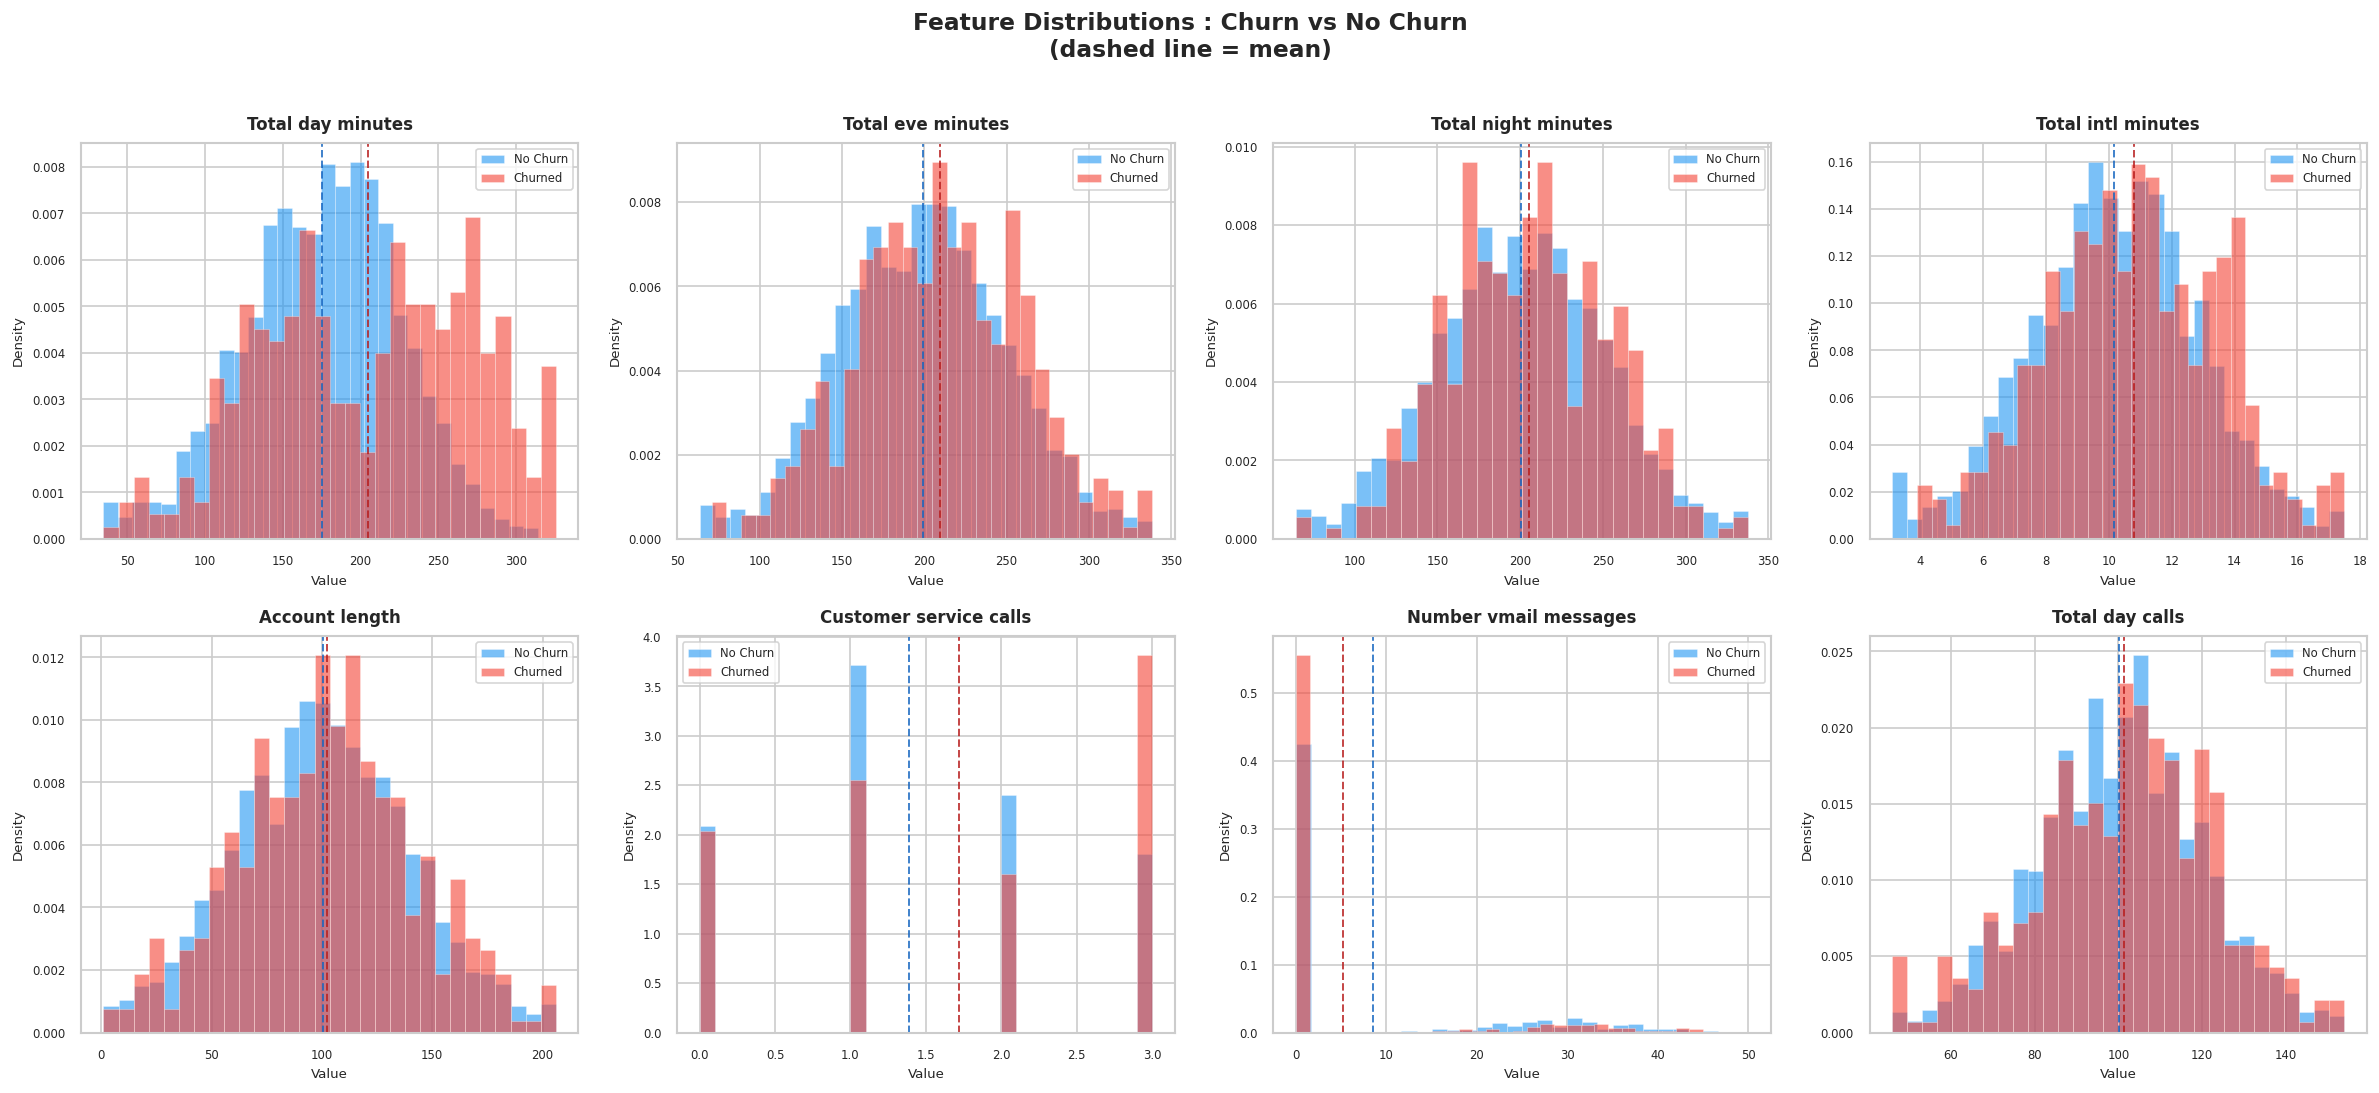

 Saved: task2_01_histograms.png


In [33]:
# Distribution histograms for all numeric features
key_num = ['Total day minutes','Total eve minutes','Total night minutes',
           'Total intl minutes','Account length','Customer service calls',
           'Number vmail messages','Total day calls']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(key_num):
    ax = axes[i]
    churn_false = df_eda[df_eda['Churn']==False][col]
    churn_true  = df_eda[df_eda['Churn']==True ][col]

    ax.hist(churn_false, bins=30, alpha=0.6, color='#2196F3',
            label='No Churn', density=True, edgecolor='white', linewidth=0.3)
    ax.hist(churn_true,  bins=30, alpha=0.6, color='#F44336',
            label='Churned', density=True, edgecolor='white', linewidth=0.3)

    ax.set_title(col, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

    # Add mean lines
    ax.axvline(churn_false.mean(), color='#1565C0', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.axvline(churn_true.mean(),  color='#B71C1C', linestyle='--', linewidth=1.2, alpha=0.8)

plt.suptitle('Feature Distributions : Churn vs No Churn\n(dashed line = mean)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task2_01_histograms.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: task2_01_histograms.png')

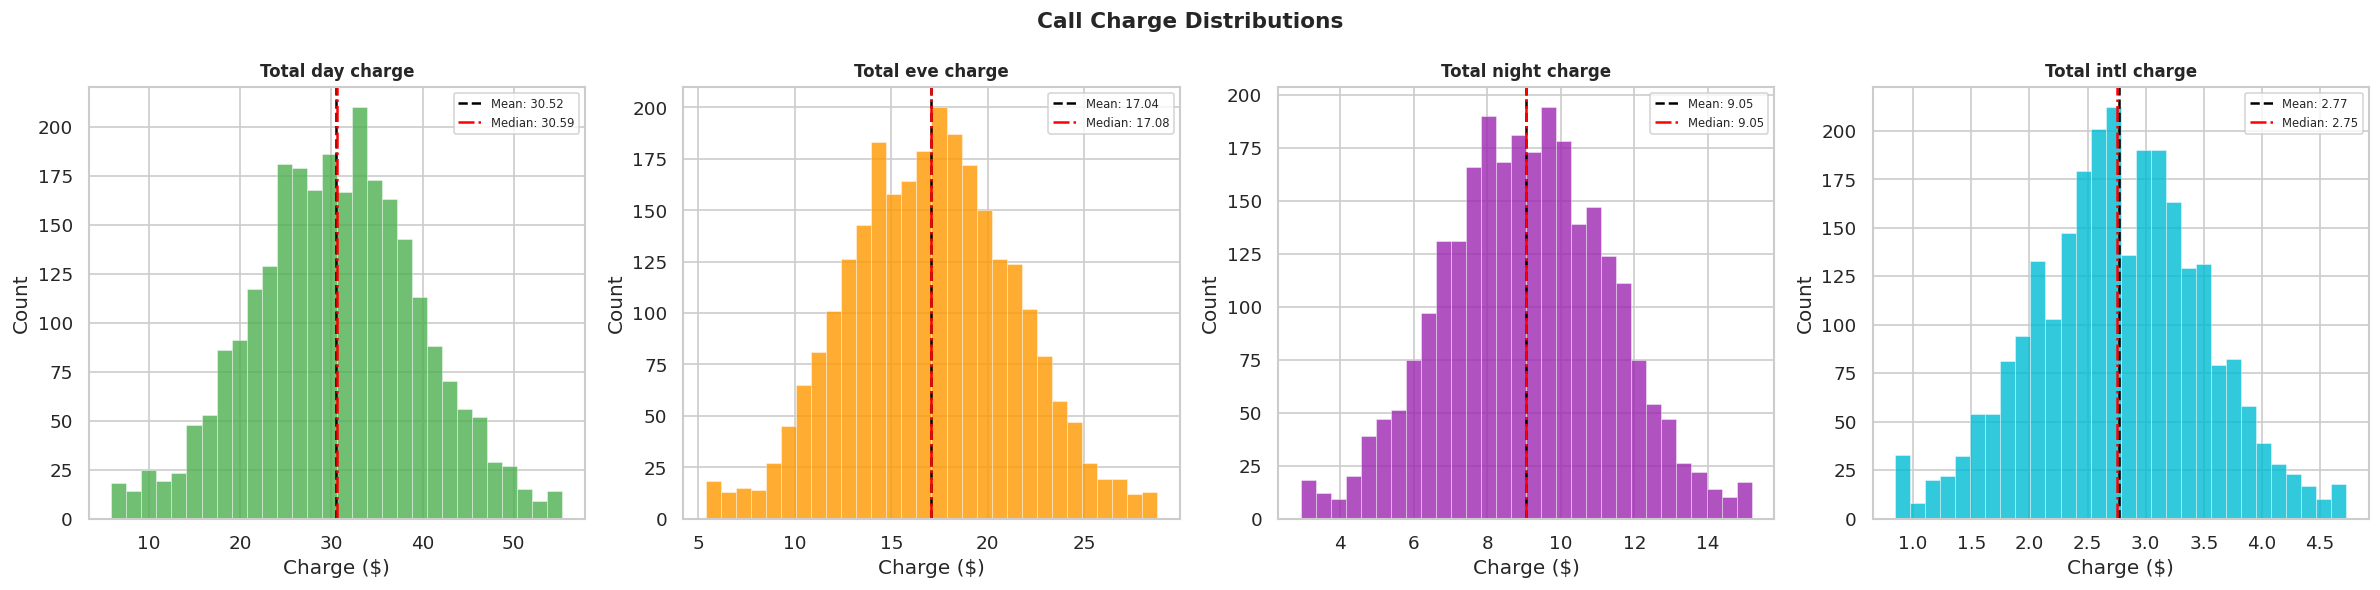

 Saved: task2_02_charge_distributions.png


In [34]:
#  Charge columns distributions
charge_cols = ['Total day charge','Total eve charge',
               'Total night charge','Total intl charge']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#4CAF50','#FF9800','#9C27B0','#00BCD4']

for ax, col, color in zip(axes, charge_cols, colors):
    ax.hist(df_eda[col], bins=30, color=color, alpha=0.8,
            edgecolor='white', linewidth=0.3)
    ax.axvline(df_eda[col].mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {df_eda[col].mean():.2f}')
    ax.axvline(df_eda[col].median(), color='red', linestyle='-.',
               linewidth=1.5, label=f'Median: {df_eda[col].median():.2f}')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Charge ($)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Call Charge Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_02_charge_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: task2_02_charge_distributions.png')

##  Bivariate Analysis  Boxplots by Churn

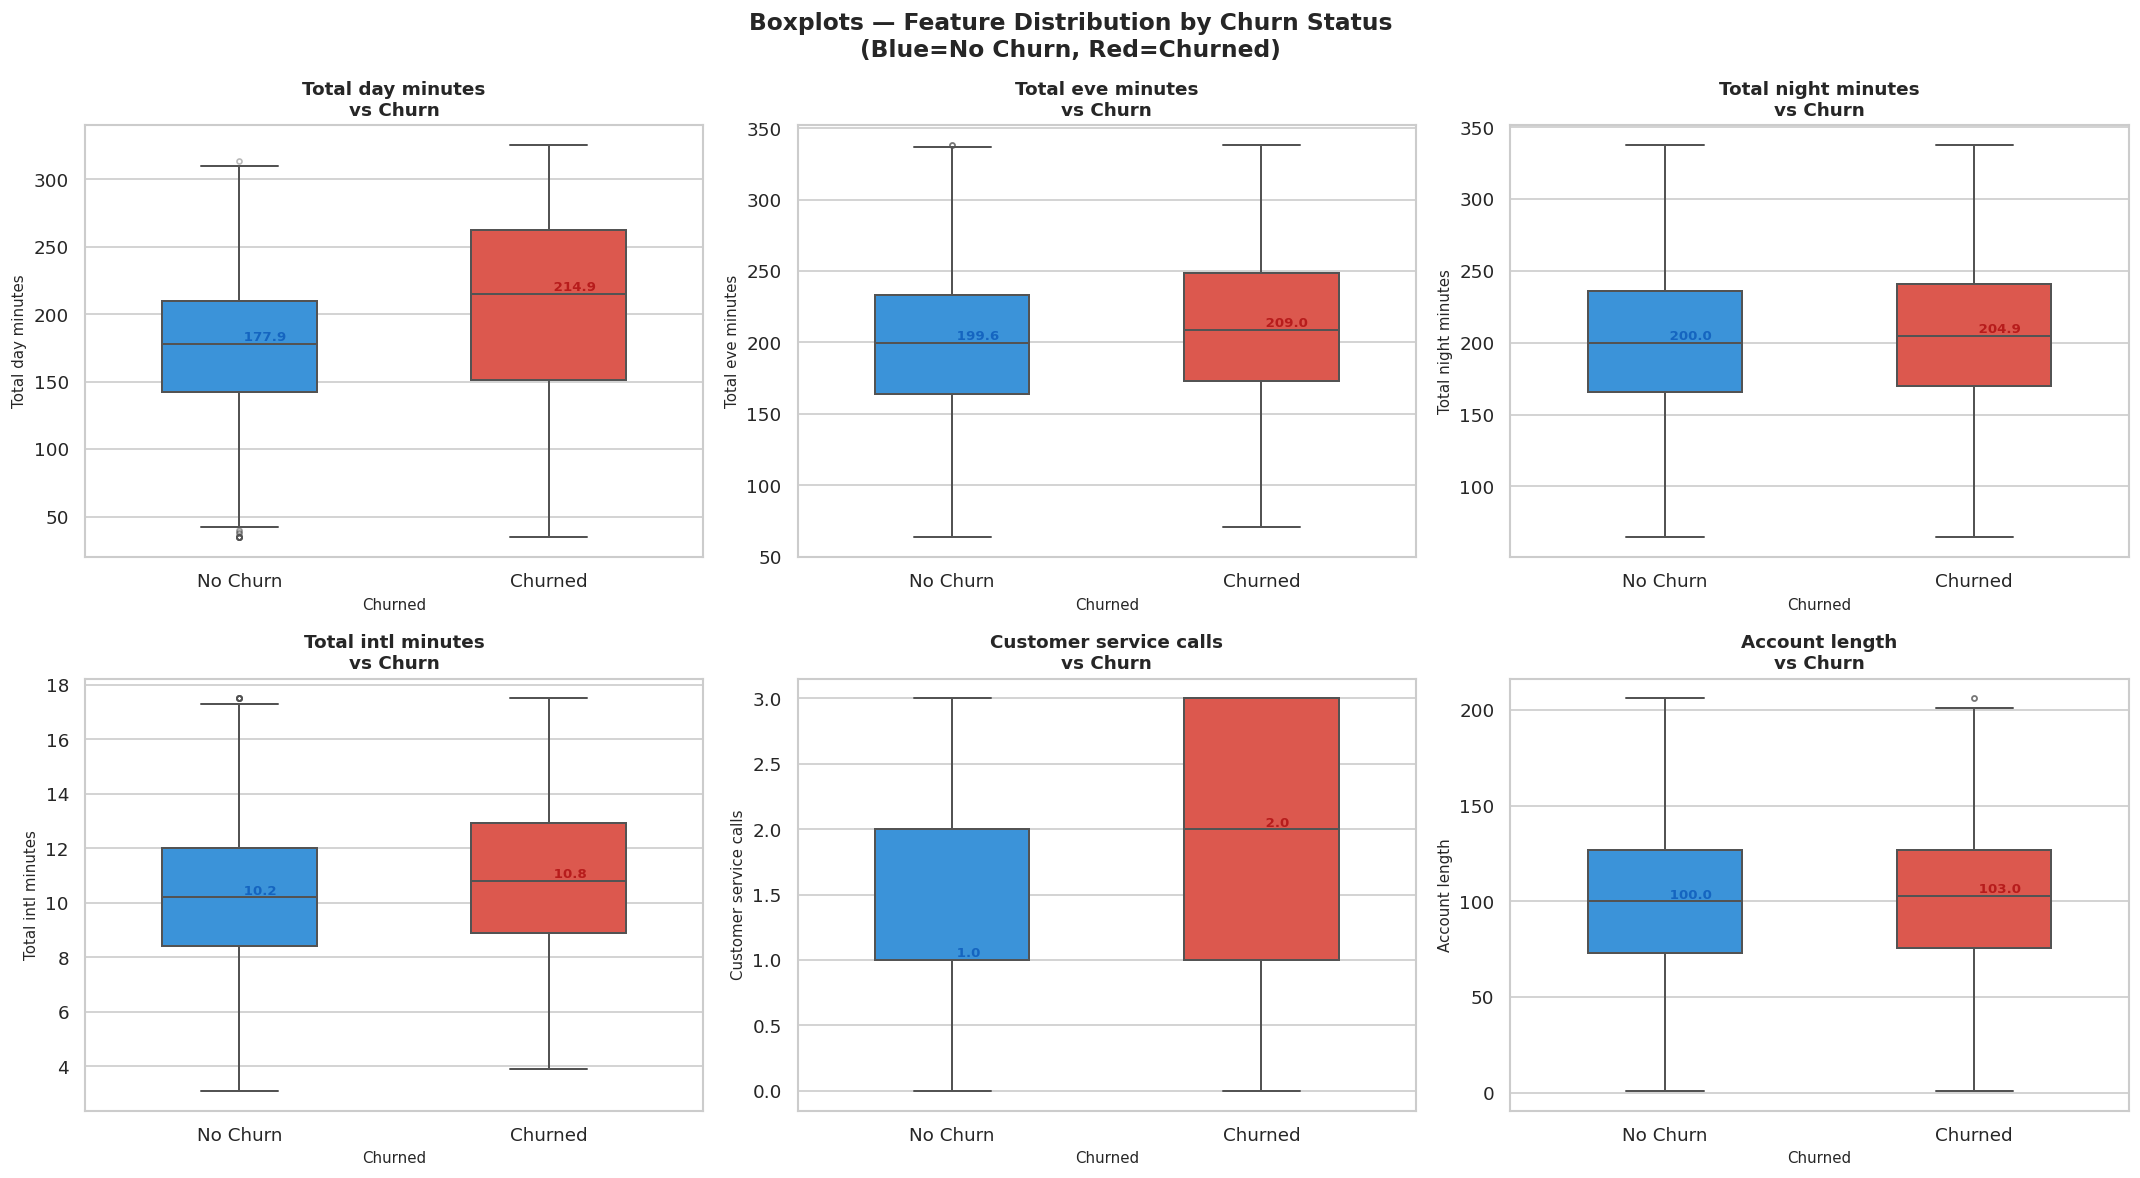

Saved: task2_03_boxplots_churn.png


In [35]:
#  Boxplots: feature vs Churn
box_cols = ['Total day minutes','Total eve minutes','Total night minutes',
            'Total intl minutes','Customer service calls','Account length']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Seaborn needs string keys when Churn is bool → convert
df_box = df_eda.copy()
df_box['Churn_label'] = df_box['Churn'].map({True:'Churned', False:'No Churn'})
pal = {'No Churn':'#2196F3', 'Churned':'#F44336'}

for i, col in enumerate(box_cols):
    sns.boxplot(data=df_box, x='Churn_label', y=col,
                palette=pal, ax=axes[i], order=['No Churn','Churned'],
                width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(f'{col}\nvs Churn', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Churned', fontsize=9)
    axes[i].set_ylabel(col, fontsize=9)

    # Annotate medians
    for tick, val in enumerate([False, True]):
        med = df_eda[df_eda['Churn']==val][col].median()
        axes[i].text(tick, med, f' {med:.1f}',
                     va='bottom', fontsize=8, fontweight='bold',
                     color='#1565C0' if not val else '#B71C1C')

plt.suptitle('Boxplots — Feature Distribution by Churn Status\n(Blue=No Churn, Red=Churned)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_03_boxplots_churn.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: task2_03_boxplots_churn.png')


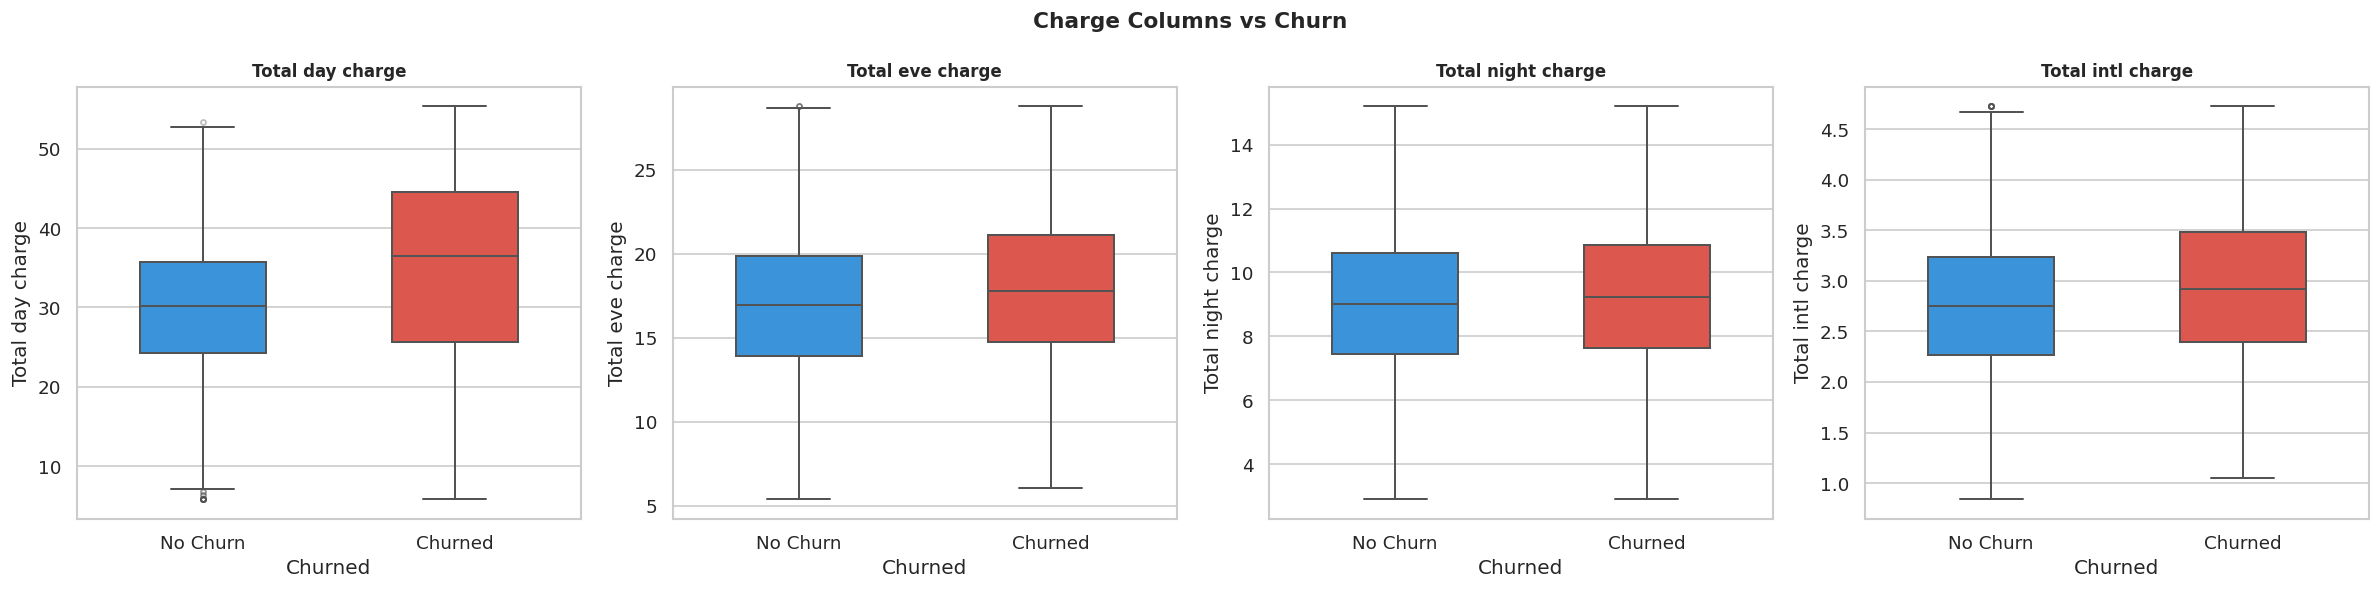

Saved: task2_04_charge_boxplots.png


In [36]:
# Charge columns vs Churn
df_box2 = df_eda.copy()
df_box2['Churn_label'] = df_box2['Churn'].map({True:'Churned', False:'No Churn'})
pal = {'No Churn':'#2196F3', 'Churned':'#F44336'}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, ['Total day charge','Total eve charge',
                           'Total night charge','Total intl charge']):
    sns.boxplot(data=df_box2, x='Churn_label', y=col,
                palette=pal, ax=ax, order=['No Churn','Churned'],
                width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Churned')

plt.suptitle('Charge Columns vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_04_charge_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: task2_04_charge_boxplots.png')


## Correlation Analysis  Heatmap




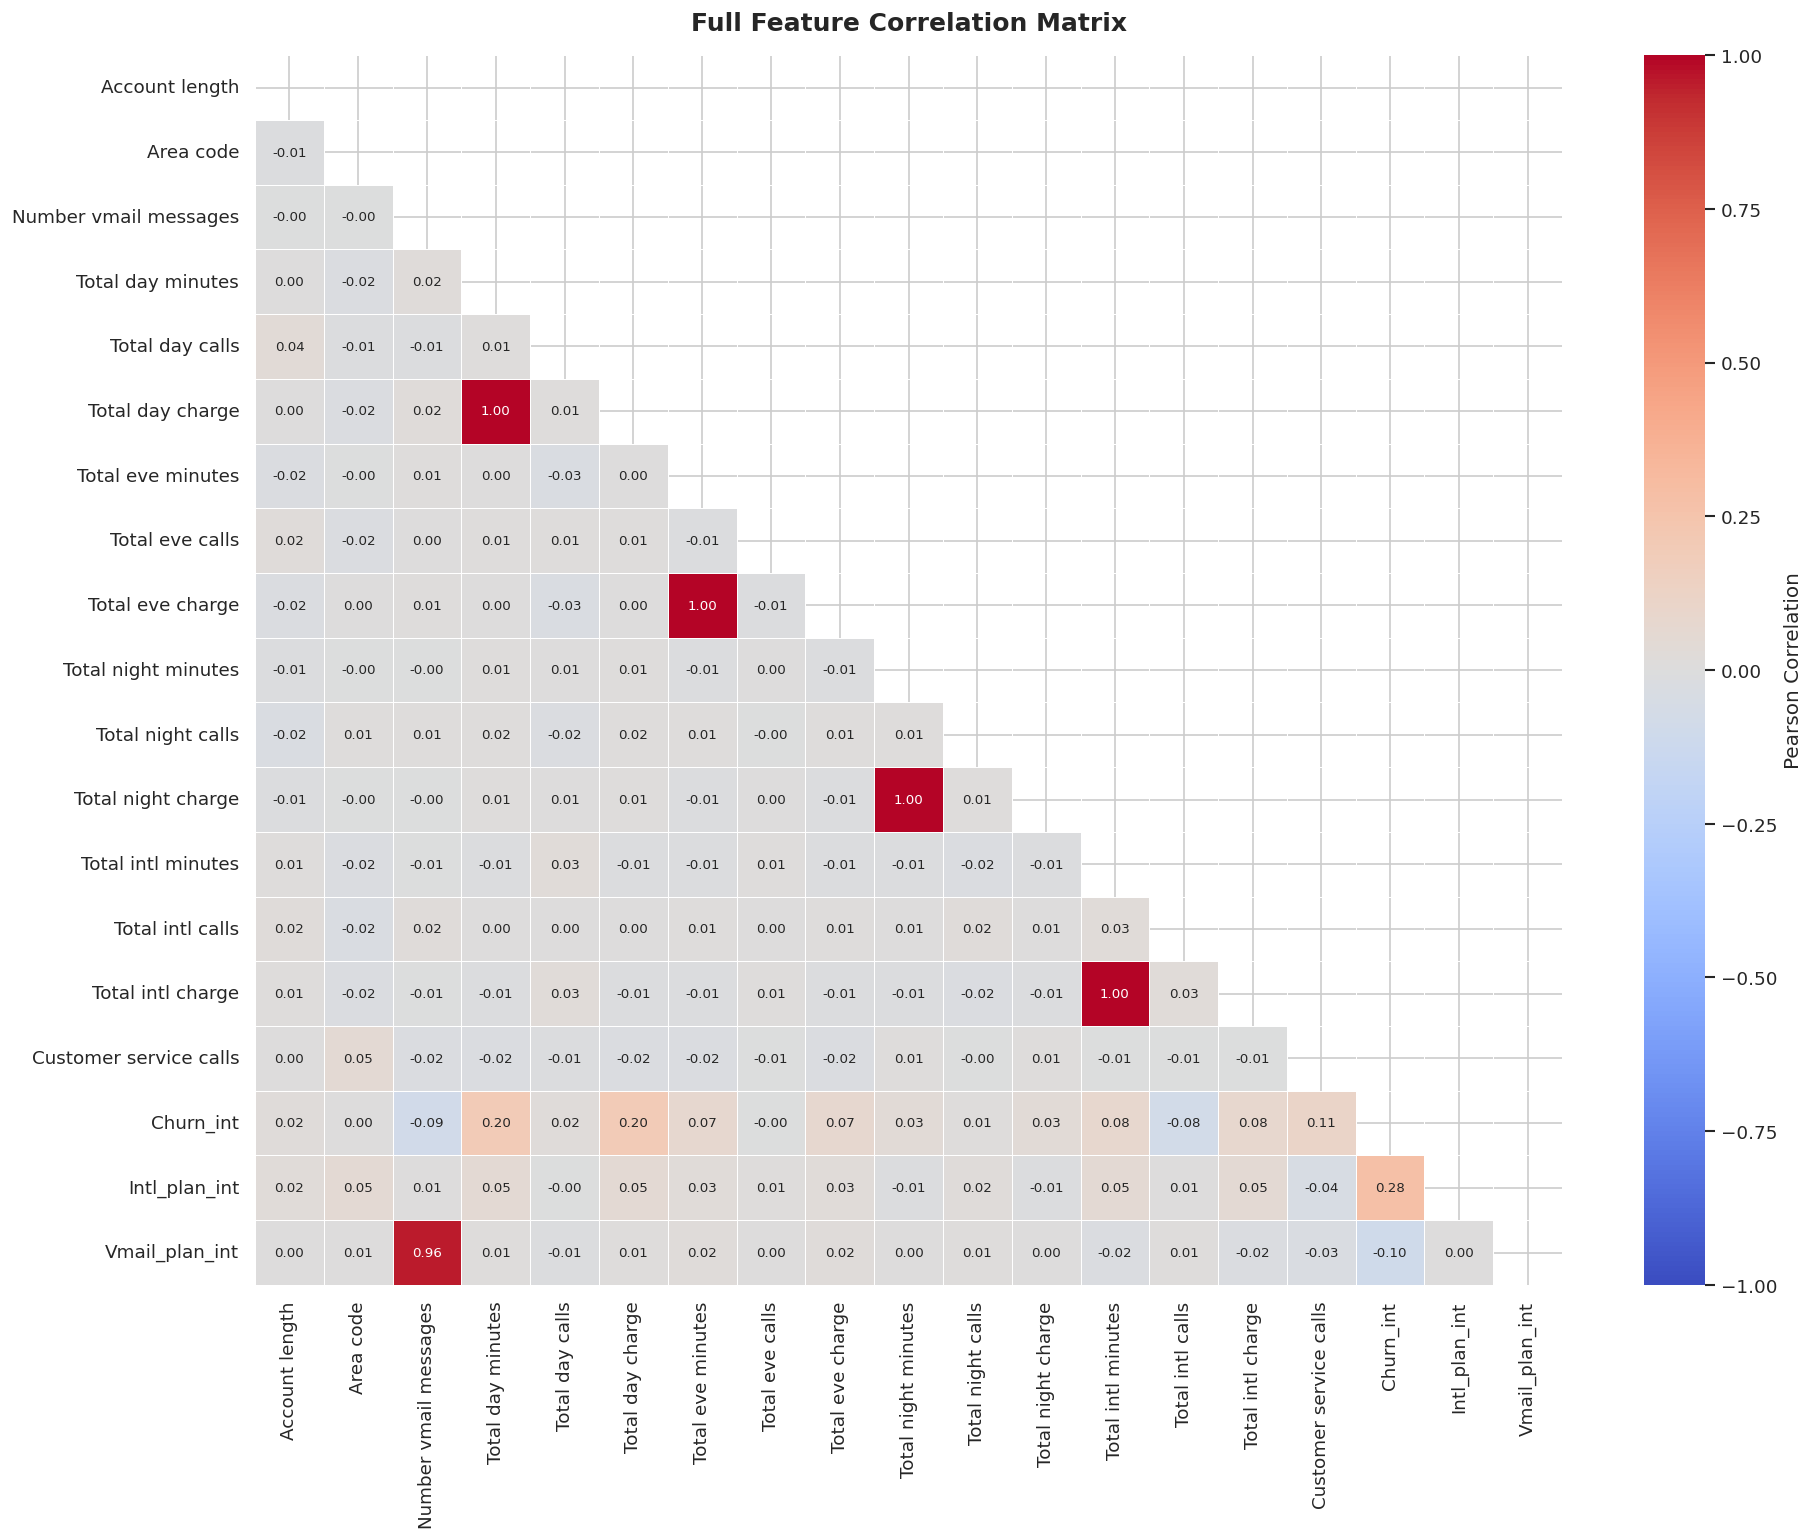

Saved: task2_05_correlation_full.png


In [37]:
#  Full correlation matrix
# Encode Churn as 0/1 for correlation
df_corr = df_eda.copy()
df_corr['Churn_int']         = df_corr['Churn'].astype(int)
df_corr['Intl_plan_int']     = (df_corr['International plan'] == 'Yes').astype(int)
df_corr['Vmail_plan_int']    = (df_corr['Voice mail plan'] == 'Yes').astype(int)

corr_cols = [c for c in df_corr.select_dtypes(include=['float64','int64']).columns
             if c not in []]
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask,
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8}, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Full Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('task2_05_correlation_full.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: task2_05_correlation_full.png')

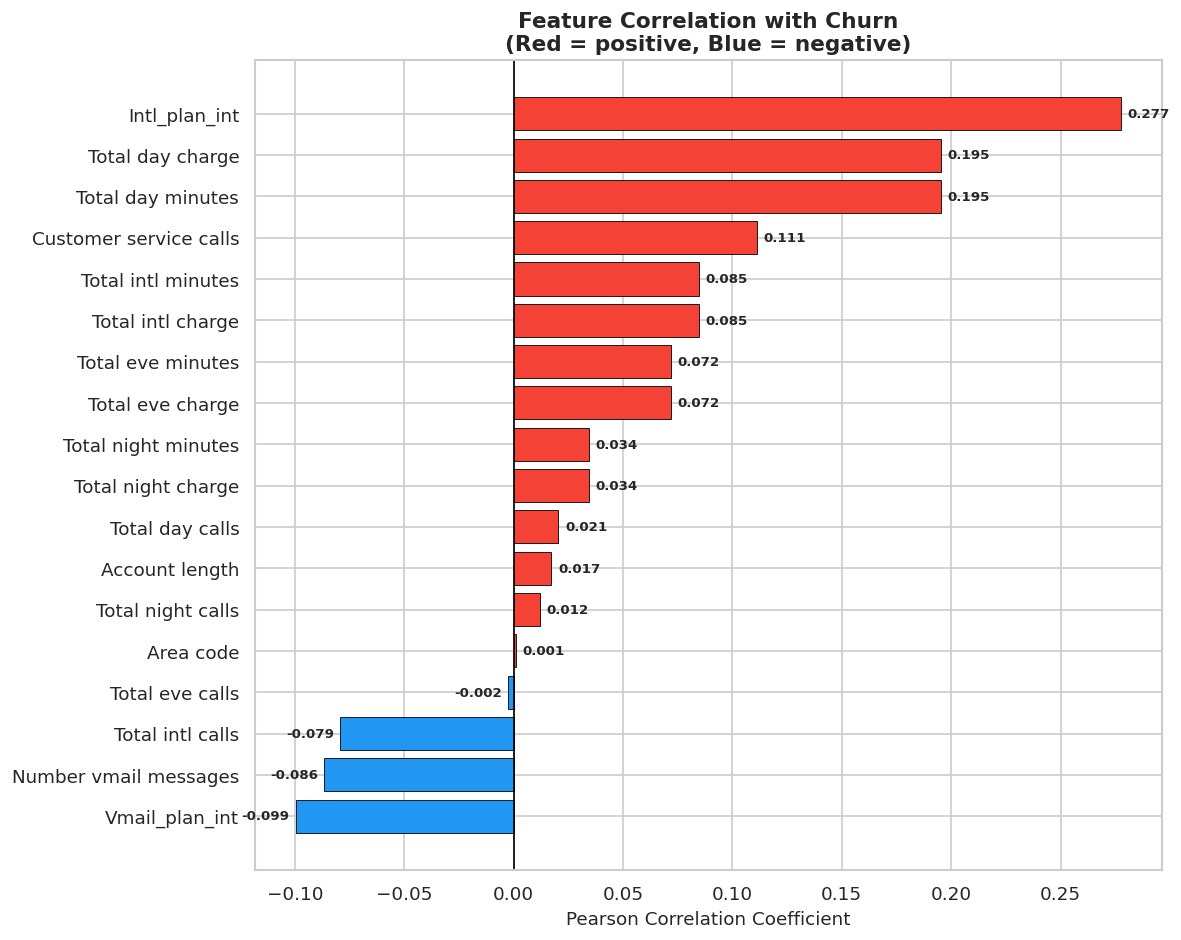

 Saved: task2_06_churn_correlation.png

 Top features correlated with Churn:
Intl_plan_int            0.28
Total day charge         0.20
Total day minutes        0.20
Customer service calls   0.11
Vmail_plan_int           0.10
Number vmail messages    0.09
Total intl minutes       0.08
Total intl charge        0.08


In [38]:
#  Correlation with CHURN only
churn_corr = df_corr[corr_cols].corr()['Churn_int'].drop('Churn_int').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#F44336' if v > 0 else '#2196F3' for v in churn_corr.values]
bars = ax.barh(churn_corr.index, churn_corr.values,
               color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=11)
ax.set_title('Feature Correlation with Churn\n(Red = positive, Blue = negative)',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, churn_corr.values):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('task2_06_churn_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: task2_06_churn_correlation.png')
print('\n Top features correlated with Churn:')
print(churn_corr.abs().sort_values(ascending=False).head(8).to_string())

## Scatter Plots : Feature Relationships

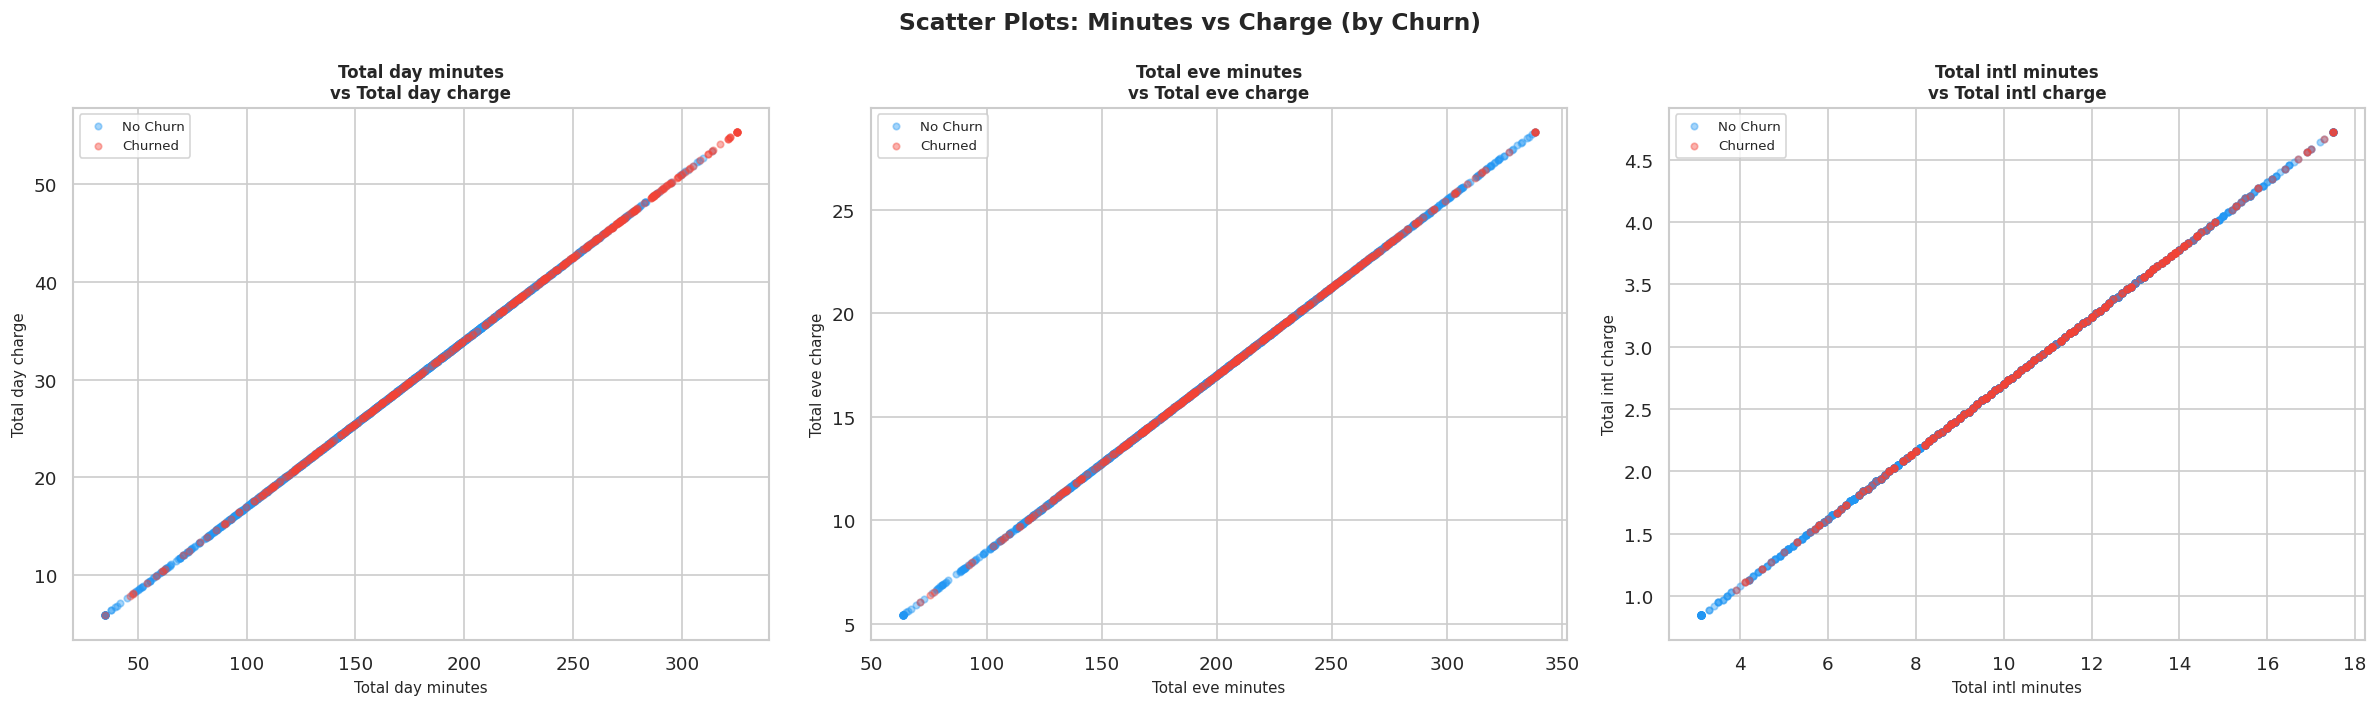

 Saved: task2_07_scatter_minutes_charge.png


In [39]:
#  Scatter: Day Minutes vs Day Charge
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
scatter_pairs = [
    ('Total day minutes',  'Total day charge'),
    ('Total eve minutes',  'Total eve charge'),
    ('Total intl minutes', 'Total intl charge'),
]
palette_scatter = {False:'#2196F3', True:'#F44336'}

for ax, (xcol, ycol) in zip(axes, scatter_pairs):
    for churn_val, color in palette_scatter.items():
        mask = df_eda['Churn'] == churn_val
        ax.scatter(df_eda.loc[mask, xcol], df_eda.loc[mask, ycol],
                   color=color, alpha=0.4, s=15,
                   label='Churned' if churn_val else 'No Churn')
    ax.set_xlabel(xcol, fontsize=9)
    ax.set_ylabel(ycol, fontsize=9)
    ax.set_title(f'{xcol}\nvs {ycol}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Scatter Plots: Minutes vs Charge (by Churn)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_07_scatter_minutes_charge.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: task2_07_scatter_minutes_charge.png')

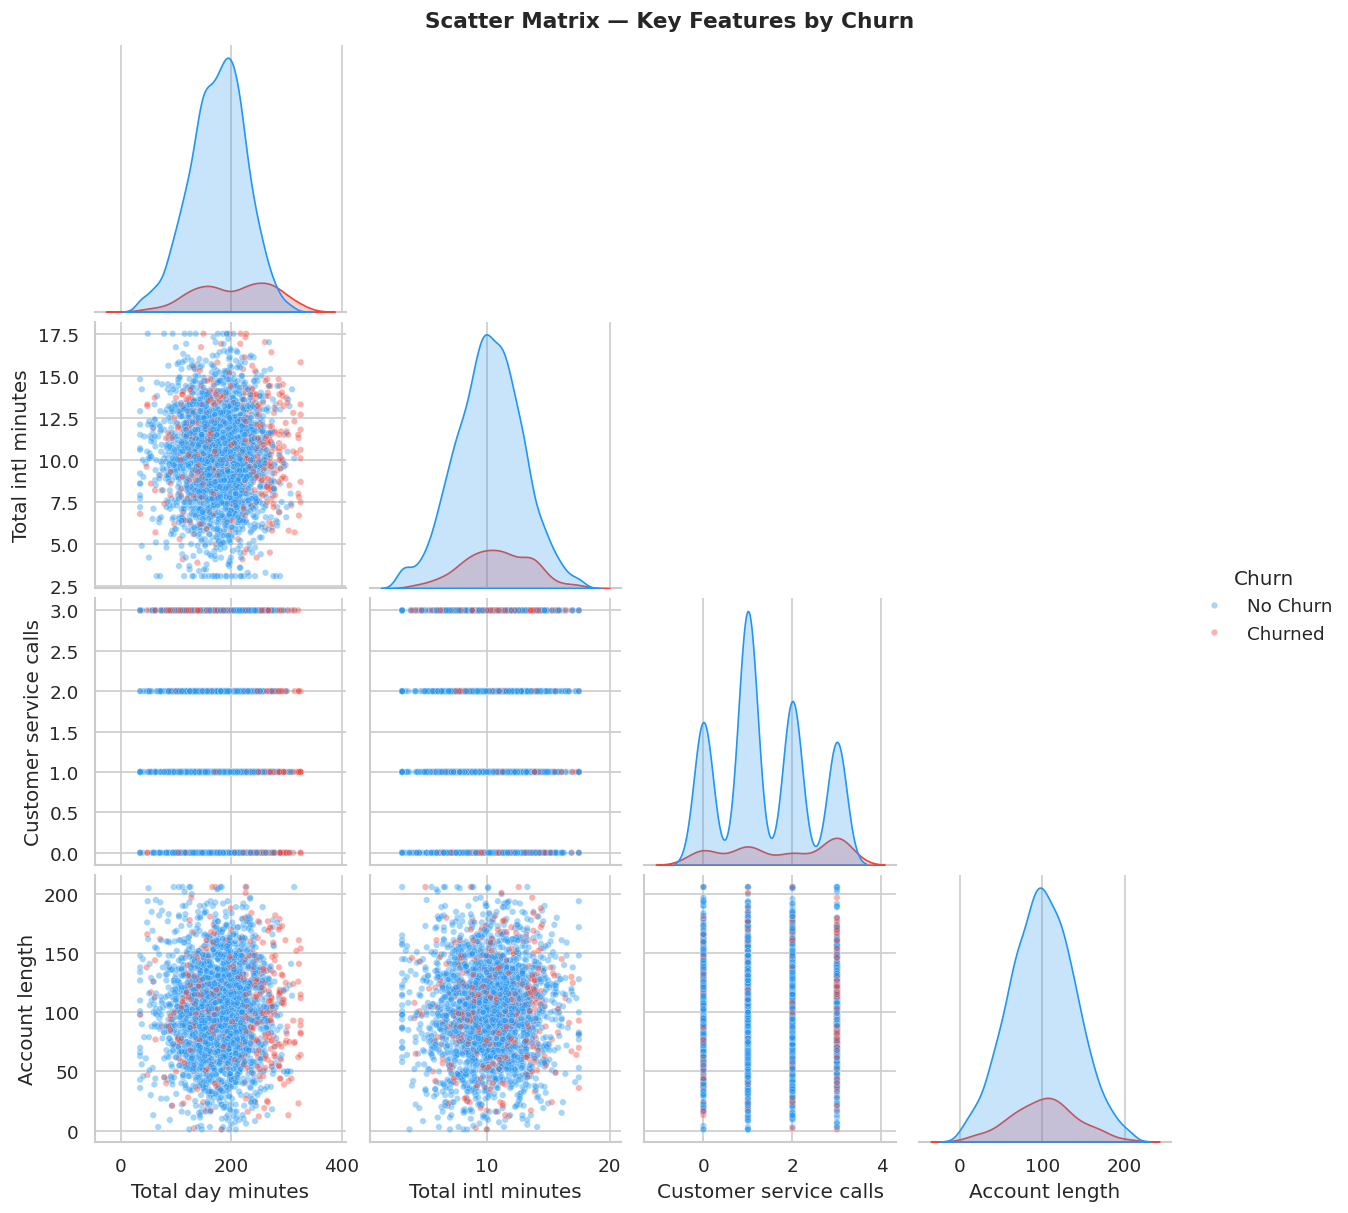

 Saved: task2_08_pairplot.png


In [40]:
#  Scatter matrix (pairplot)
pair_cols = ['Total day minutes','Total intl minutes',
             'Customer service calls','Account length','Churn']
df_pair = df_eda[pair_cols].copy()
df_pair['Churn'] = df_pair['Churn'].map({True:'Churned', False:'No Churn'})

g = sns.pairplot(df_pair, hue='Churn',
                 palette={'No Churn':'#2196F3','Churned':'#F44336'},
                 plot_kws={'alpha':0.4, 's':15},
                 diag_kind='kde', corner=True)
g.figure.suptitle('Scatter Matrix — Key Features by Churn',
                  fontsize=13, fontweight='bold', y=1.01)
plt.savefig('task2_08_pairplot.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: task2_08_pairplot.png')

## Churn vs Key Features <a id='16'></a>

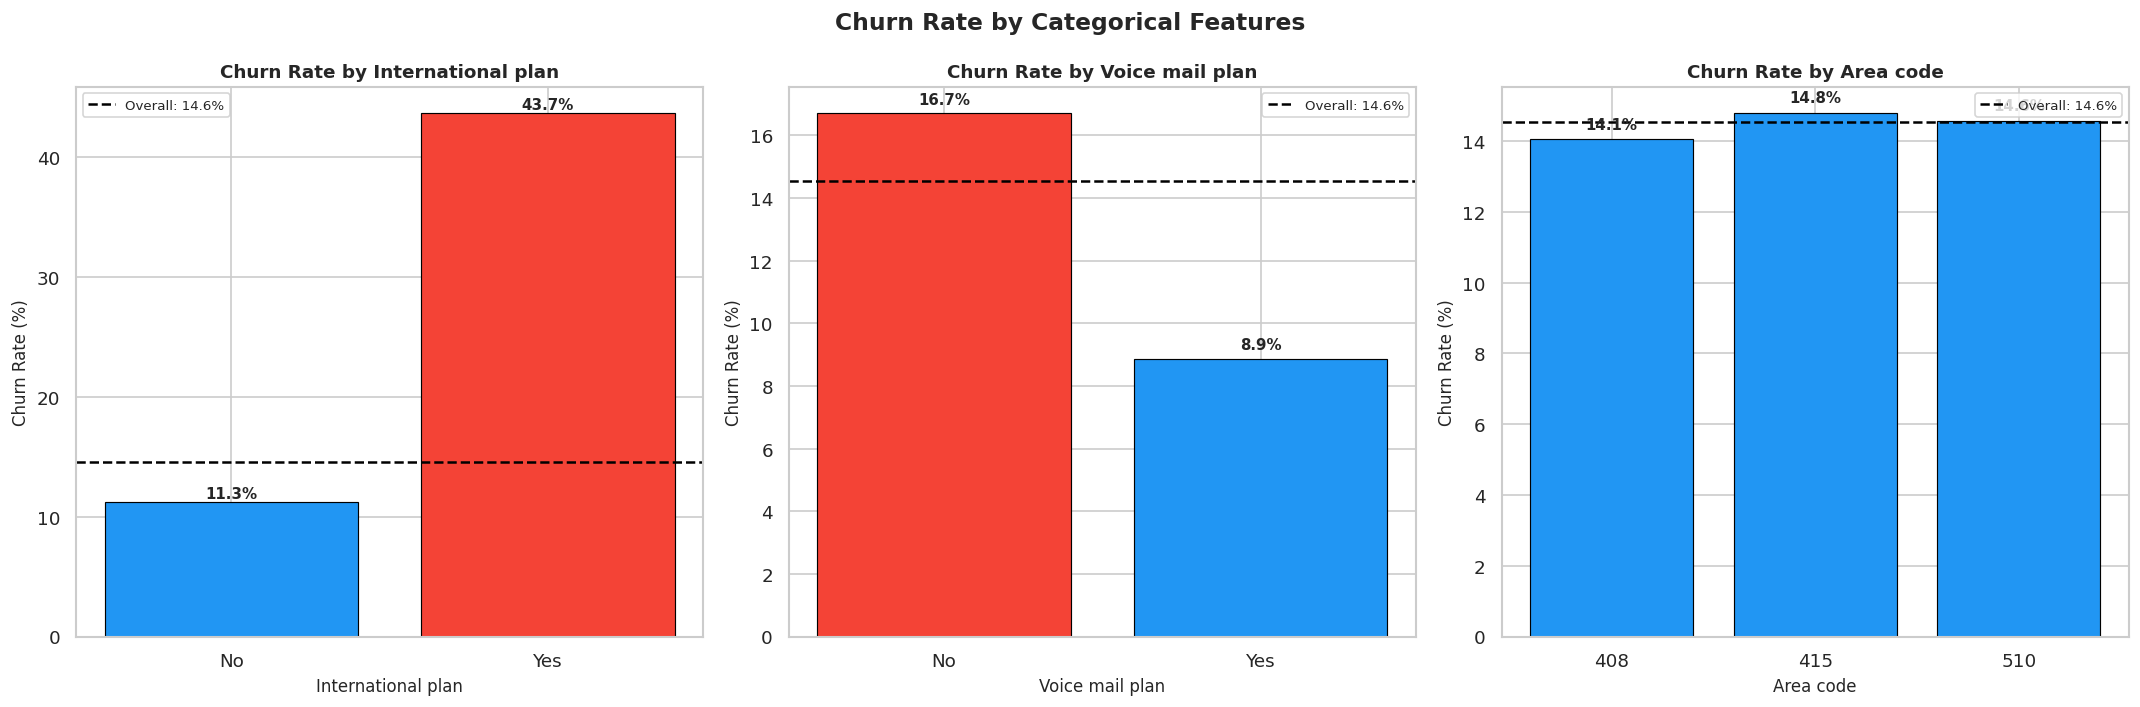

Saved: task2_09_churn_by_category.png


In [41]:
#  Churn rate by categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cat_features = ['International plan', 'Voice mail plan', 'Area code']

for ax, col in zip(axes, cat_features):
    churn_rate = df_eda.groupby(col)['Churn'].mean() * 100
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                  color=['#F44336' if v > 15 else '#2196F3' for v in churn_rate.values],
                  edgecolor='black', linewidth=0.7)
    ax.axhline(y=df_eda['Churn'].mean()*100, color='black',
               linestyle='--', linewidth=1.5, label=f'Overall: {df_eda["Churn"].mean()*100:.1f}%')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Churn Rate (%)', fontsize=10)
    ax.set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_09_churn_by_category.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: task2_09_churn_by_category.png')

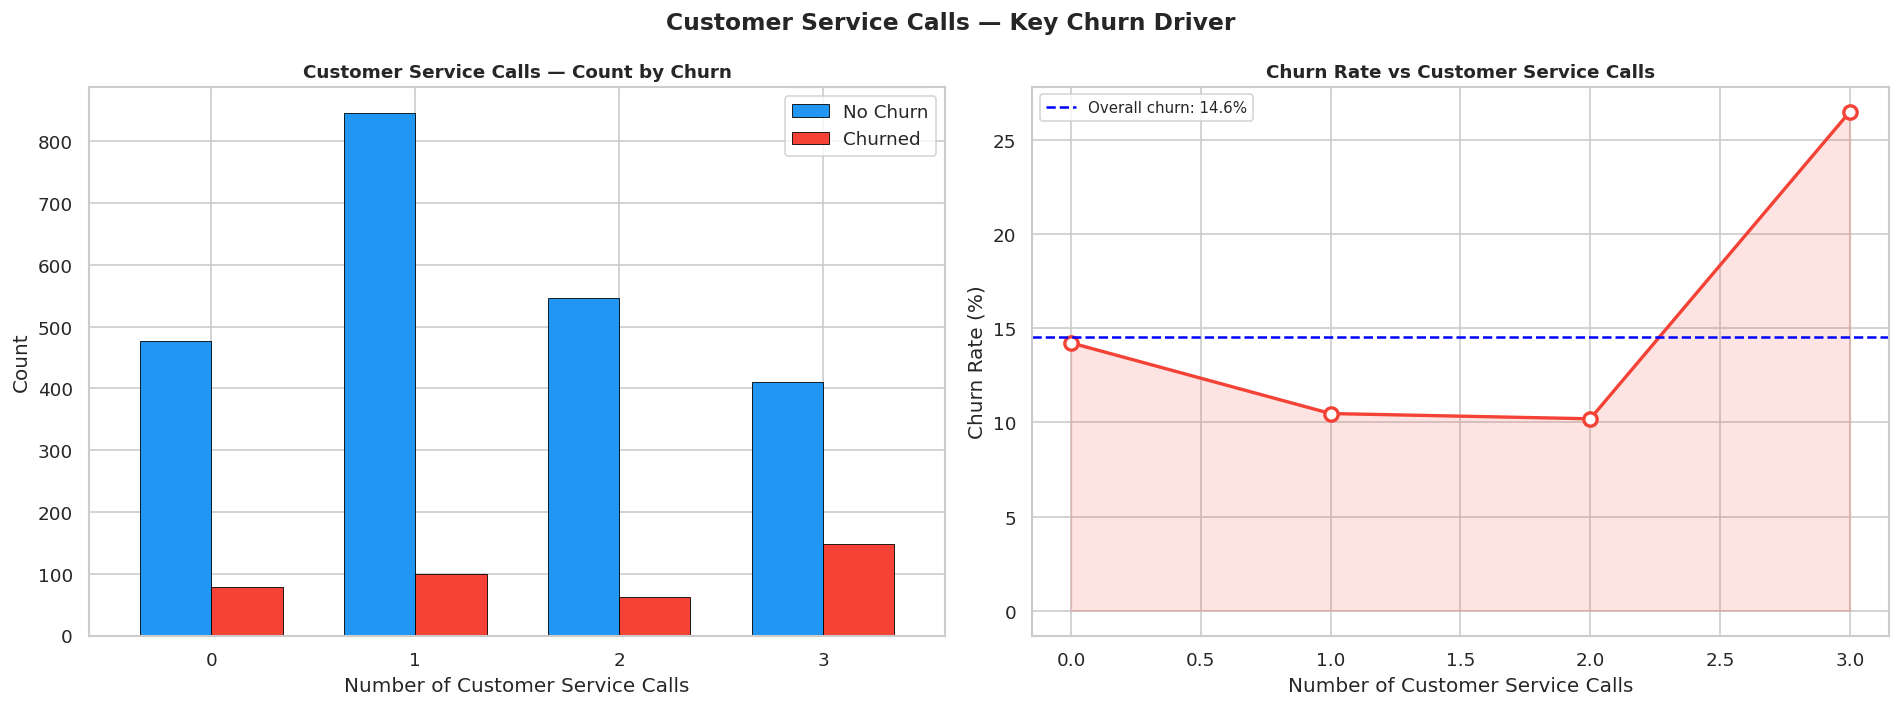

Saved: task2_10_csc_churn.png


In [42]:
# Customer service calls vs Churn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: count per service calls bucket
csc_churn = df_eda.groupby(['Customer service calls','Churn']).size().unstack(fill_value=0)
csc_churn.plot(kind='bar', ax=axes[0], color=['#2196F3','#F44336'],
               edgecolor='black', linewidth=0.5, width=0.7)
axes[0].set_title('Customer Service Calls — Count by Churn',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Number of Customer Service Calls')
axes[0].set_ylabel('Count')
axes[0].legend(['No Churn','Churned'])
axes[0].tick_params(axis='x', rotation=0)

# Right: churn rate per service calls bucket
csc_rate = df_eda.groupby('Customer service calls')['Churn'].mean() * 100
axes[1].plot(csc_rate.index, csc_rate.values, marker='o',
             color='#F44336', linewidth=2, markersize=8, markerfacecolor='white',
             markeredgewidth=2)
axes[1].axhline(df_eda['Churn'].mean()*100, color='blue', linestyle='--',
                linewidth=1.5, label=f'Overall churn: {df_eda["Churn"].mean()*100:.1f}%')
axes[1].fill_between(csc_rate.index, csc_rate.values,
                     alpha=0.15, color='#F44336')
axes[1].set_title('Churn Rate vs Customer Service Calls',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Customer Service Calls')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend(fontsize=9)

plt.suptitle('Customer Service Calls — Key Churn Driver',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_10_csc_churn.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: task2_10_csc_churn.png')

In [43]:
# EDA Summary
print('='*65)
print('   TASK 2 : EDA KEY FINDINGS')
print('='*65)

df_c = df_corr.copy()
top_corr = df_c[corr_cols].corr()['Churn_int'].drop('Churn_int').abs().sort_values(ascending=False)

print(f'\n🔹 Dataset: {df_eda.shape[0]:,} rows × {df_eda.shape[1]} columns')
print(f'🔹 Overall Churn Rate: {df_eda["Churn"].mean()*100:.1f}%')
print(f'\n🔹 Top 5 features correlated with Churn:')
for feat, val in top_corr.head(5).items():
    print(f'   {feat:<35} r = {val:.3f}')

print(f'\n🔹 Churn rate with International Plan = Yes: '
      f'{df_eda[df_eda["International plan"]=="Yes"]["Churn"].mean()*100:.1f}%')
print(f'🔹 Churn rate with International Plan = No:  '
      f'{df_eda[df_eda["International plan"]=="No"]["Churn"].mean()*100:.1f}%')
print(f'\n🔹 Churn rate with ≥4 service calls: '
      f'{df_eda[df_eda["Customer service calls"]>=4]["Churn"].mean()*100:.1f}%')
print(f'🔹 Churn rate with <4 service calls:  '
      f'{df_eda[df_eda["Customer service calls"]<4]["Churn"].mean()*100:.1f}%')
print('='*65)

   TASK 2 : EDA KEY FINDINGS

🔹 Dataset: 2,666 rows × 20 columns
🔹 Overall Churn Rate: 14.6%

🔹 Top 5 features correlated with Churn:
   Intl_plan_int                       r = 0.277
   Total day charge                    r = 0.195
   Total day minutes                   r = 0.195
   Customer service calls              r = 0.111
   Vmail_plan_int                      r = 0.099

🔹 Churn rate with International Plan = Yes: 43.7%
🔹 Churn rate with International Plan = No:  11.3%

🔹 Churn rate with ≥4 service calls: nan%
🔹 Churn rate with <4 service calls:  14.6%



# Task 3: Basic Data Visualization


## Bar Plots :  Categorical Features <a id='17'></a>

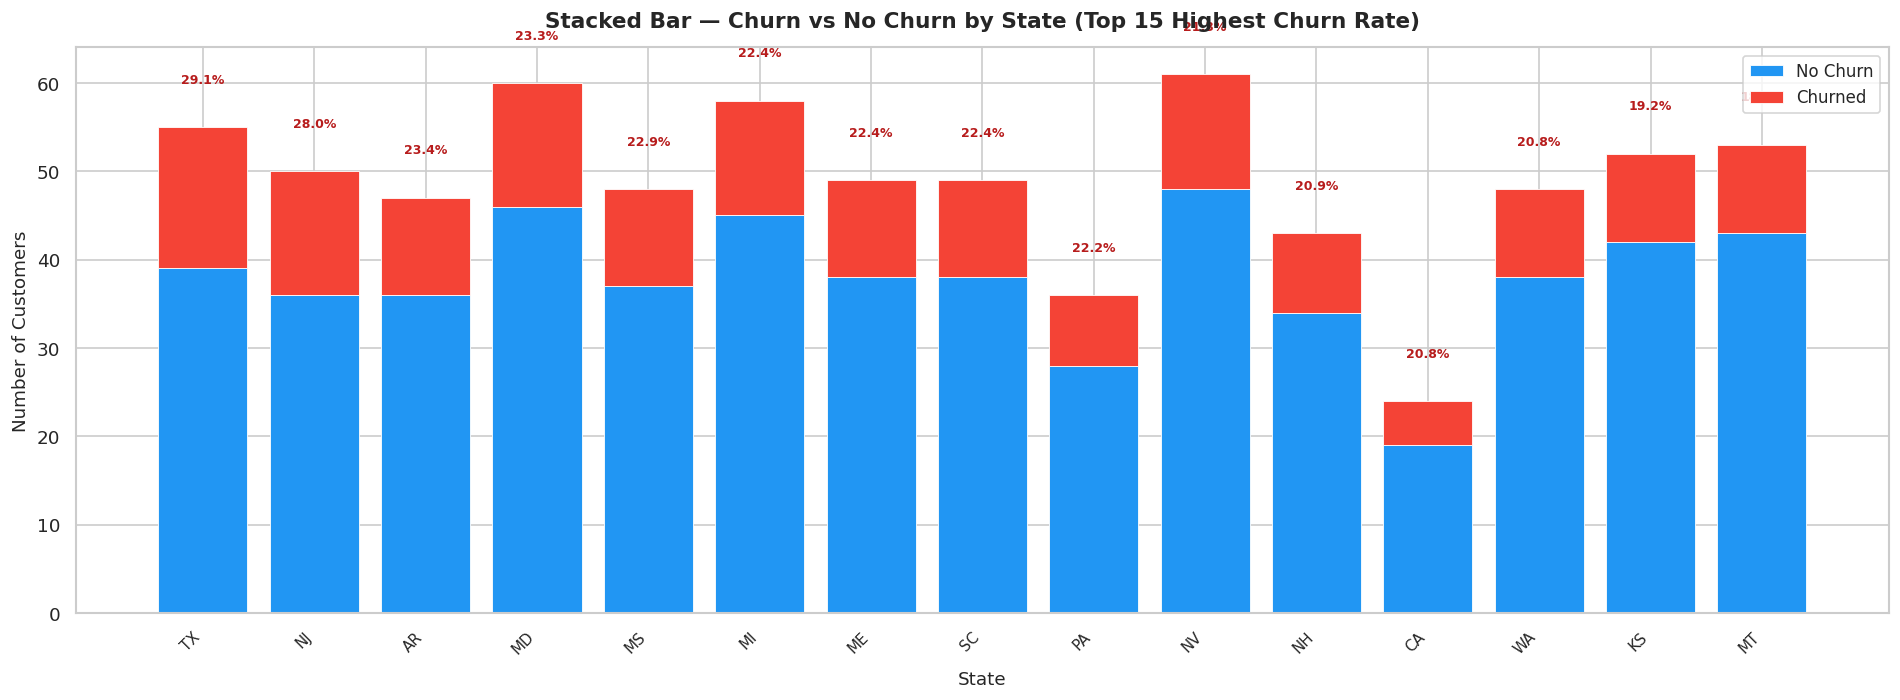

Saved: task3_01_stacked_bar_state.png


In [44]:
# Stacked bar: Churn by State (top 15)
state_churn = df_eda.groupby('State')['Churn'].agg(['sum','count'])
state_churn.columns = ['Churned','Total']
state_churn['No Churn'] = state_churn['Total'] - state_churn['Churned']
state_churn['Churn Rate %'] = (state_churn['Churned']/state_churn['Total']*100).round(1)
state_churn = state_churn.sort_values('Churn Rate %', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(16, 6))
x = range(len(state_churn))
bars_no  = ax.bar(x, state_churn['No Churn'], label='No Churn',
                  color='#2196F3', edgecolor='white', linewidth=0.5)
bars_ch  = ax.bar(x, state_churn['Churned'],  label='Churned',
                  bottom=state_churn['No Churn'],
                  color='#F44336', edgecolor='white', linewidth=0.5)

ax.set_xticks(list(x))
ax.set_xticklabels(state_churn.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('State', fontsize=11, labelpad=8)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_title('Stacked Bar — Churn vs No Churn by State (Top 15 Highest Churn Rate)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper right')

# Annotate churn rate on top
for i, (_, row) in enumerate(state_churn.iterrows()):
    ax.text(i, row['Total']+5, f'{row["Churn Rate %"]}%',
            ha='center', fontsize=7.5, fontweight='bold', color='#B71C1C')

plt.tight_layout()
plt.savefig('task3_01_stacked_bar_state.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: task3_01_stacked_bar_state.png')

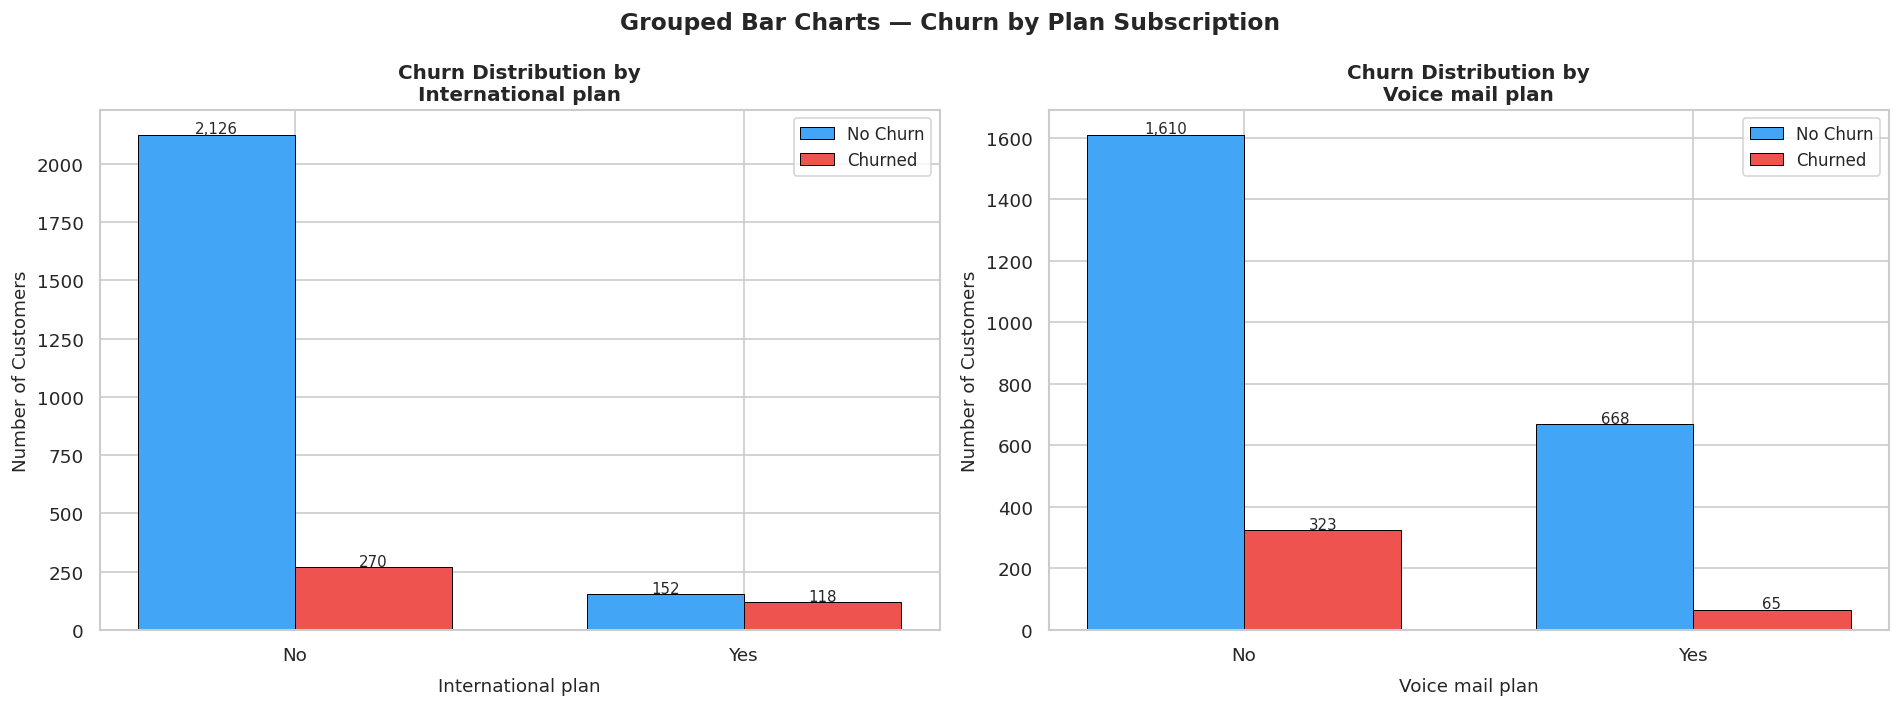

 Saved: task3_02_grouped_bar_plans.png


In [45]:
#  Grouped bar: plan subscriptions vs Churn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col in zip(axes, ['International plan', 'Voice mail plan']):
    ct = pd.crosstab(df_eda[col], df_eda['Churn'])
    ct.columns = ['No Churn', 'Churned']
    x_pos = np.arange(len(ct))
    width = 0.35

    bars1 = ax.bar(x_pos - width/2, ct['No Churn'], width,
                   label='No Churn', color='#42A5F5', edgecolor='black', linewidth=0.6)
    bars2 = ax.bar(x_pos + width/2, ct['Churned'],  width,
                   label='Churned',  color='#EF5350', edgecolor='black', linewidth=0.6)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(ct.index, fontsize=11)
    ax.set_xlabel(col, fontsize=11, labelpad=8)
    ax.set_ylabel('Number of Customers', fontsize=11)
    ax.set_title(f'Churn Distribution by\n{col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                f'{int(bar.get_height()):,}', ha='center', fontsize=9)

plt.suptitle('Grouped Bar Charts — Churn by Plan Subscription',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_02_grouped_bar_plans.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: task3_02_grouped_bar_plans.png')

## 18. Line Charts — Usage Trends <a id='18'></a>

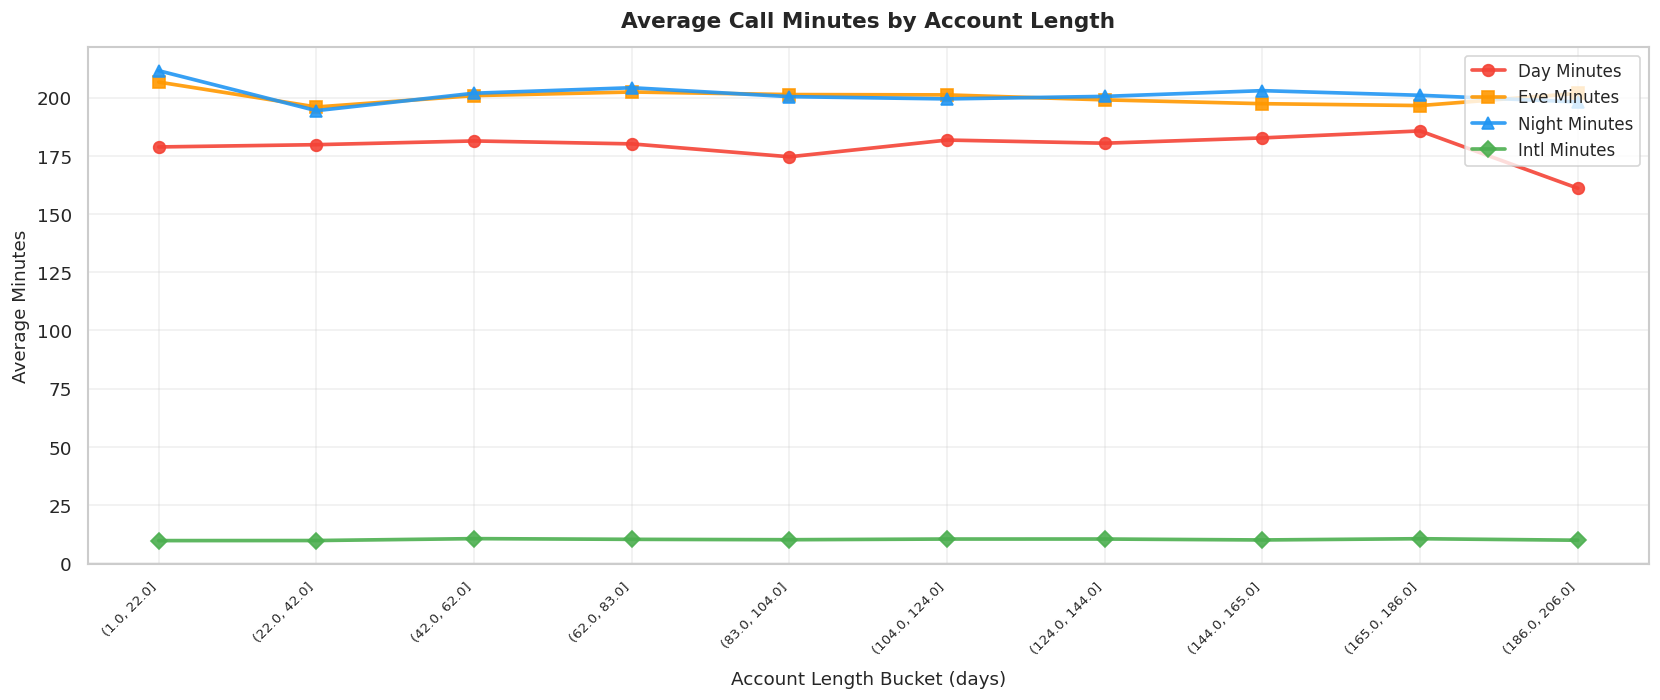

Saved: task3_03_line_usage_trend.png


In [46]:
# Avg usage trend by Account Length buckets
df_line = df_eda.copy()
df_line['Account Bucket'] = pd.cut(df_line['Account length'],
                                    bins=10, precision=0)

usage_trend = df_line.groupby('Account Bucket')[
    ['Total day minutes','Total eve minutes',
     'Total night minutes','Total intl minutes']
].mean()

fig, ax = plt.subplots(figsize=(14, 6))

colors_line = ['#F44336','#FF9800','#2196F3','#4CAF50']
markers     = ['o','s','^','D']
labels      = ['Day Minutes','Eve Minutes','Night Minutes','Intl Minutes']

for col, color, marker, label in zip(
        ['Total day minutes','Total eve minutes',
         'Total night minutes','Total intl minutes'],
        colors_line, markers, labels):
    ax.plot(range(len(usage_trend)), usage_trend[col],
            color=color, marker=marker, linewidth=2.2,
            markersize=7, label=label, alpha=0.9)

ax.set_xticks(range(len(usage_trend)))
ax.set_xticklabels([str(b) for b in usage_trend.index],
                    rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Account Length Bucket (days)', fontsize=11, labelpad=8)
ax.set_ylabel('Average Minutes', fontsize=11)
ax.set_title('Average Call Minutes by Account Length',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task3_03_line_usage_trend.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: task3_03_line_usage_trend.png')

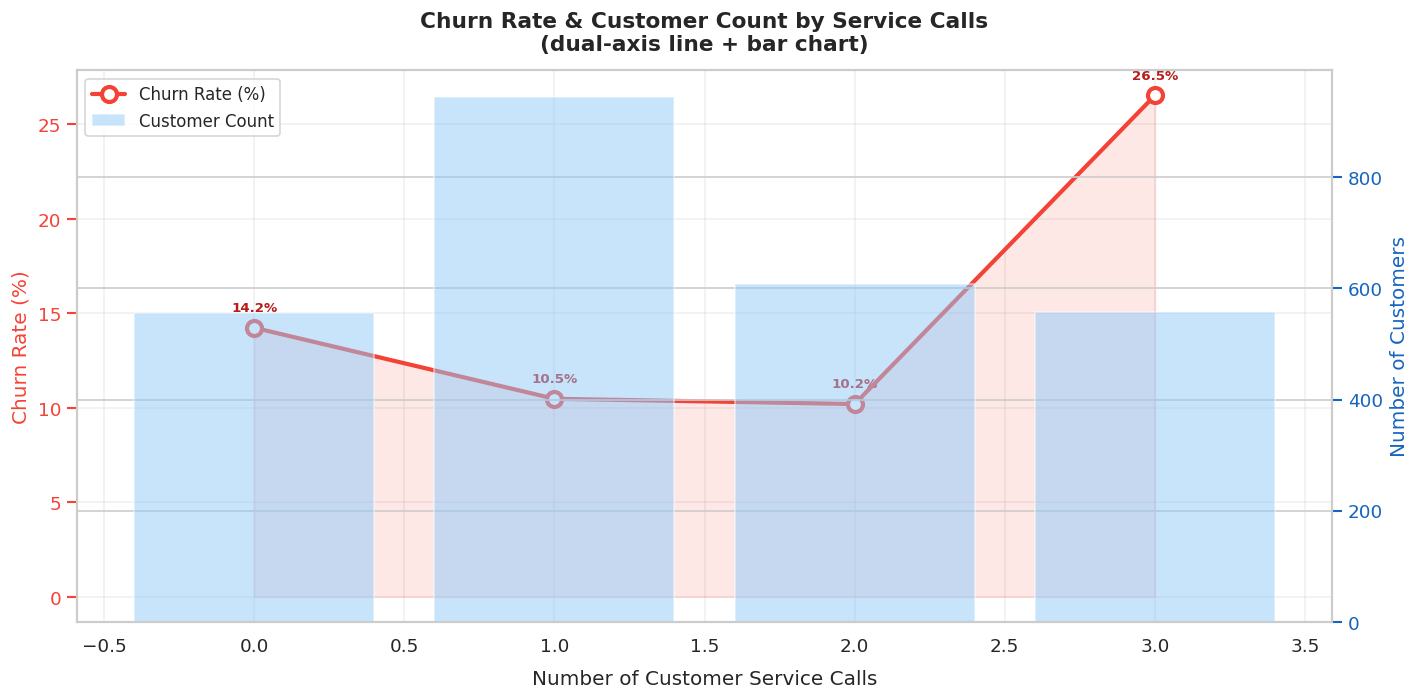

 Saved: task3_04_line_churn_csc.png


In [47]:
# Churn rate trend by Customer Service Calls
csc_trend = df_eda.groupby('Customer service calls').agg(
    Churn_Rate=('Churn', lambda x: x.mean()*100),
    Count=('Churn','count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Line: churn rate
line = ax1.plot(csc_trend['Customer service calls'],
                csc_trend['Churn_Rate'],
                color='#F44336', marker='o', linewidth=2.5,
                markersize=9, markerfacecolor='white',
                markeredgewidth=2.5, label='Churn Rate (%)', zorder=5)
ax1.fill_between(csc_trend['Customer service calls'],
                 csc_trend['Churn_Rate'], alpha=0.12, color='#F44336')

# Bar: count
ax2.bar(csc_trend['Customer service calls'],
        csc_trend['Count'], color='#90CAF9',
        alpha=0.5, label='Customer Count', zorder=2)

ax1.set_xlabel('Number of Customer Service Calls', fontsize=12, labelpad=8)
ax1.set_ylabel('Churn Rate (%)', fontsize=12, color='#F44336')
ax2.set_ylabel('Number of Customers', fontsize=12, color='#1565C0')
ax1.tick_params(axis='y', colors='#F44336')
ax2.tick_params(axis='y', colors='#1565C0')

ax1.set_title('Churn Rate & Customer Count by Service Calls\n'
              '(dual-axis line + bar chart)',
              fontsize=13, fontweight='bold', pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)

for _, row in csc_trend.iterrows():
    ax1.annotate(f'{row["Churn_Rate"]:.1f}%',
                 (row['Customer service calls'], row['Churn_Rate']),
                 textcoords='offset points', xytext=(0,10),
                 ha='center', fontsize=8, fontweight='bold', color='#B71C1C')

plt.tight_layout()
plt.savefig('task3_04_line_churn_csc.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: task3_04_line_churn_csc.png')

## 19. Scatter Plots — Customized <a id='19'></a>

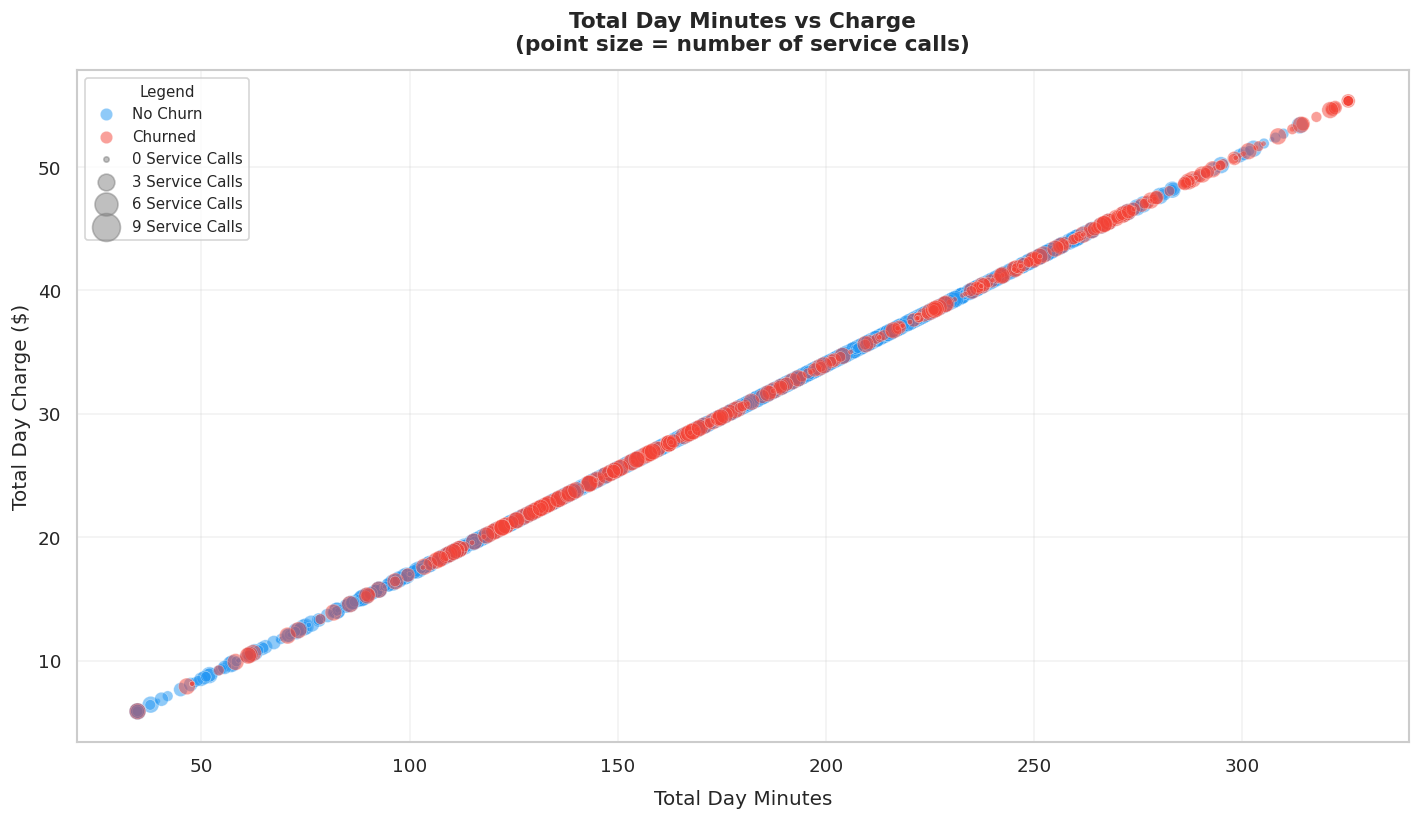

Saved: task3_05_scatter_custom.png


In [48]:
# Day minutes vs Day charge, sized by CSC
fig, ax = plt.subplots(figsize=(12, 7))

for churn_val, color, label in [(False,'#2196F3','No Churn'),(True,'#F44336','Churned')]:
    sub = df_eda[df_eda['Churn']==churn_val]
    sc  = ax.scatter(sub['Total day minutes'], sub['Total day charge'],
                     c=color, alpha=0.5, s=sub['Customer service calls']*30+10,
                     label=label, edgecolors='white', linewidths=0.3)

ax.set_xlabel('Total Day Minutes', fontsize=12, labelpad=8)
ax.set_ylabel('Total Day Charge ($)', fontsize=12)
ax.set_title('Total Day Minutes vs Charge\n(point size = number of service calls)',
             fontsize=13, fontweight='bold', pad=12)

# Custom legend for size
for csc_val in [0, 3, 6, 9]:
    ax.scatter([], [], c='grey', alpha=0.5,
               s=csc_val*30+10, label=f'{csc_val} Service Calls')

ax.legend(fontsize=9, loc='upper left',
          title='Legend', title_fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('task3_05_scatter_custom.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: task3_05_scatter_custom.png')

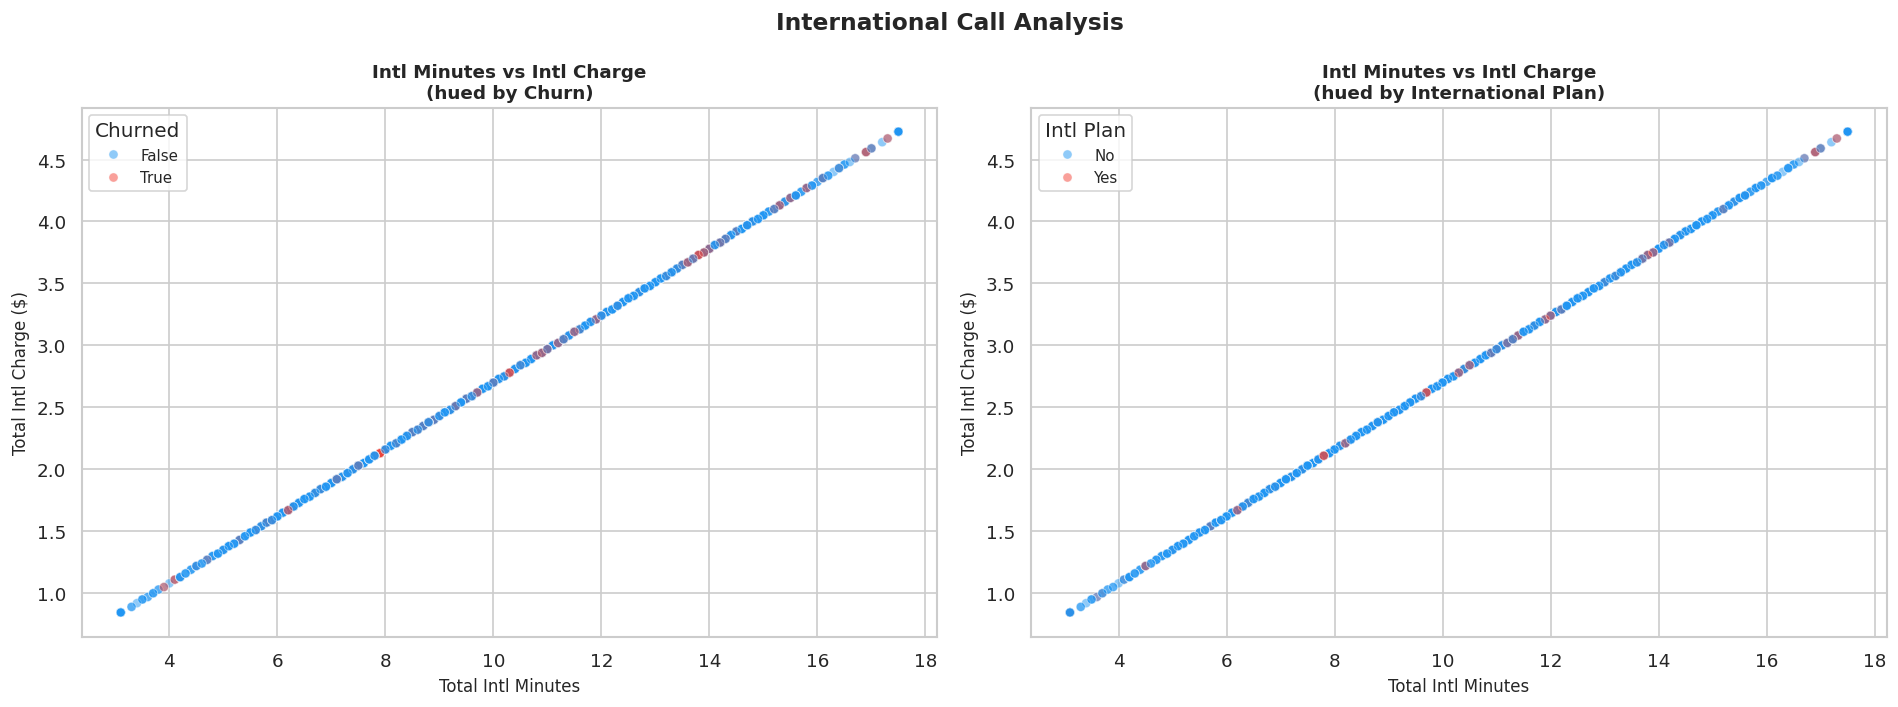

 Saved: task3_06_scatter_intl.png


In [49]:
# International minutes vs Charge, hued by plan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: color by churn
sns.scatterplot(data=df_eda, x='Total intl minutes', y='Total intl charge',
                hue='Churn', palette={False:'#2196F3', True:'#F44336'},
                alpha=0.5, s=30, ax=axes[0])
axes[0].set_title('Intl Minutes vs Intl Charge\n(hued by Churn)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Total Intl Minutes', fontsize=10)
axes[0].set_ylabel('Total Intl Charge ($)', fontsize=10)
axes[0].legend(title='Churned', fontsize=9)

# Right: color by International plan
sns.scatterplot(data=df_eda, x='Total intl minutes', y='Total intl charge',
                hue='International plan', palette={'Yes':'#F44336','No':'#2196F3'},
                alpha=0.5, s=30, ax=axes[1])
axes[1].set_title('Intl Minutes vs Intl Charge\n(hued by International Plan)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Total Intl Minutes', fontsize=10)
axes[1].set_ylabel('Total Intl Charge ($)', fontsize=10)
axes[1].legend(title='Intl Plan', fontsize=9)

plt.suptitle('International Call Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_06_scatter_intl.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: task3_06_scatter_intl.png')

## 20. Export All Plots as Images <a id='20'></a>

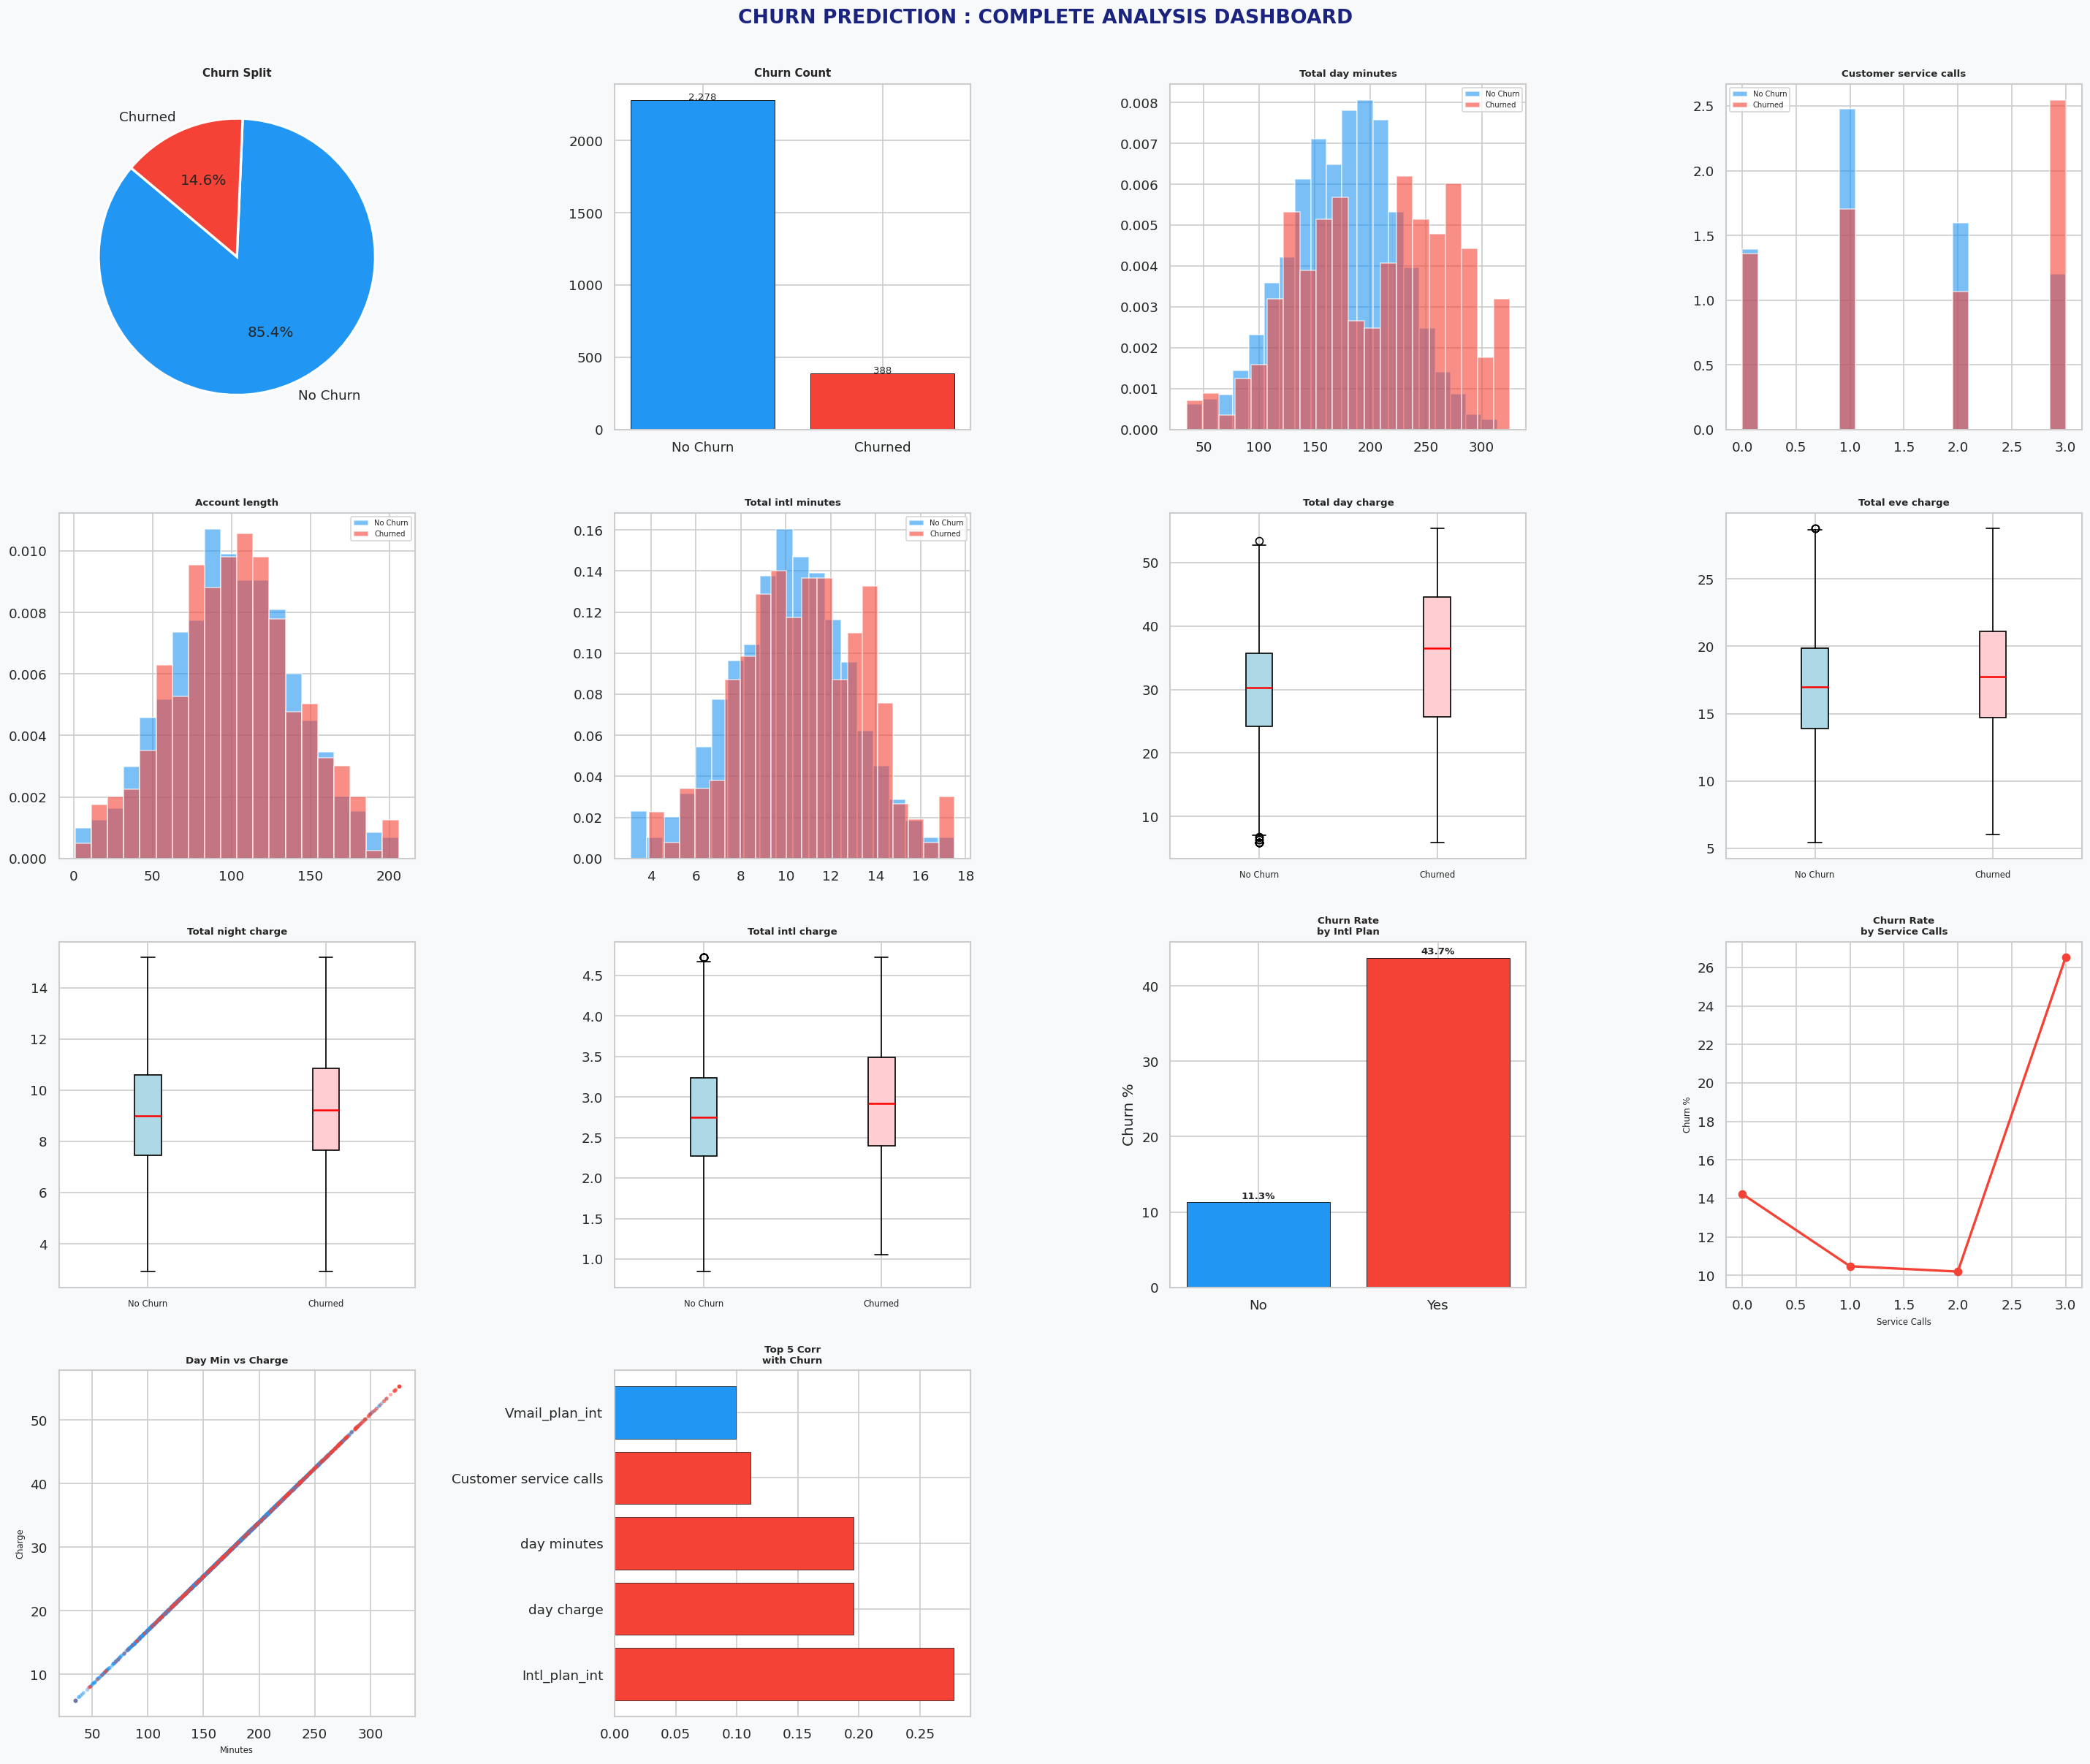

 Saved: task3_07_final_dashboard.png


In [50]:
#  Final Dashboard (all-in-one summary)
fig = plt.figure(figsize=(24, 20))
fig.patch.set_facecolor('#F8F9FA')

#  Top: churn distribution pie + bar
ax1 = fig.add_subplot(4, 4, 1)
ax2 = fig.add_subplot(4, 4, 2)
churn_c = df_eda['Churn'].value_counts()
ax1.pie(churn_c.values, labels=['No Churn','Churned'],
        autopct='%1.1f%%', colors=['#2196F3','#F44336'],
        startangle=140, wedgeprops=dict(edgecolor='white',linewidth=2))
ax1.set_title('Churn Split', fontweight='bold', fontsize=9)
ax2.bar(['No Churn','Churned'], churn_c.values, color=['#2196F3','#F44336'],
        edgecolor='black', linewidth=0.5)
for i,v in enumerate(churn_c.values): ax2.text(i,v+5,f'{v:,}',ha='center',fontsize=8)
ax2.set_title('Churn Count', fontweight='bold', fontsize=9)

#  Histograms x4
for idx, col in enumerate(['Total day minutes','Customer service calls',
                           'Account length','Total intl minutes']):
    ax = fig.add_subplot(4, 4, 3+idx)
    ax.hist(df_eda[df_eda['Churn']==False][col], bins=20, alpha=0.6, color='#2196F3', density=True, label='No Churn')
    ax.hist(df_eda[df_eda['Churn']==True ][col], bins=20, alpha=0.6, color='#F44336', density=True, label='Churned')
    ax.set_title(col, fontsize=8, fontweight='bold')
    ax.legend(fontsize=6)

#  Boxplots x4
for idx, col in enumerate(['Total day charge','Total eve charge',
                           'Total night charge','Total intl charge']):
    ax = fig.add_subplot(4, 4, 7+idx)
    data_f = [df_eda[df_eda['Churn']==False][col].values,
              df_eda[df_eda['Churn']==True ][col].values]
    bp = ax.boxplot(data_f, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=1.5))
    bp['boxes'][1].set_facecolor('#FFCDD2')
    ax.set_xticklabels(['No Churn','Churned'], fontsize=7)
    ax.set_title(col, fontsize=8, fontweight='bold')

# Bar: churn by plan
ax_p1 = fig.add_subplot(4, 4, 11)
for plan_val, color in [('No','#2196F3'),('Yes','#F44336')]:
    rate = df_eda[df_eda['International plan']==plan_val]['Churn'].mean()*100
    ax_p1.bar(plan_val, rate, color=color, edgecolor='black', linewidth=0.5)
    ax_p1.text(plan_val, rate+0.5, f'{rate:.1f}%', ha='center', fontsize=8, fontweight='bold')
ax_p1.set_title('Churn Rate\nby Intl Plan', fontsize=8, fontweight='bold')
ax_p1.set_ylabel('Churn %')

# Line: CSC vs churn rate
ax_l = fig.add_subplot(4, 4, 12)
csc_r = df_eda.groupby('Customer service calls')['Churn'].mean()*100
ax_l.plot(csc_r.index, csc_r.values, marker='o', color='#F44336', linewidth=2)
ax_l.set_title('Churn Rate\nby Service Calls', fontsize=8, fontweight='bold')
ax_l.set_xlabel('Service Calls', fontsize=7)
ax_l.set_ylabel('Churn %', fontsize=7)

# Scatter: day min vs charge
ax_s = fig.add_subplot(4, 4, 13)
for cv, color in [(False,'#2196F3'),(True,'#F44336')]:
    sub = df_eda[df_eda['Churn']==cv]
    ax_s.scatter(sub['Total day minutes'], sub['Total day charge'],
                 color=color, alpha=0.3, s=5)
ax_s.set_title('Day Min vs Charge', fontsize=8, fontweight='bold')
ax_s.set_xlabel('Minutes', fontsize=7); ax_s.set_ylabel('Charge', fontsize=7)

# Correlation bar
ax_c = fig.add_subplot(4, 4, 14)
top5 = churn_corr.abs().sort_values(ascending=False).head(5)
colors_c = ['#F44336' if churn_corr[f] > 0 else '#2196F3' for f in top5.index]
ax_c.barh([f.replace('Total ','') for f in top5.index],
           top5.values, color=colors_c, edgecolor='black', linewidth=0.4)
ax_c.set_title('Top 5 Corr\nwith Churn', fontsize=8, fontweight='bold')

plt.suptitle('CHURN PREDICTION : COMPLETE ANALYSIS DASHBOARD',
             fontsize=16, fontweight='bold', y=1.005,
             color='#1A237E')
plt.tight_layout(h_pad=2.5, w_pad=2.5)
plt.savefig('task3_07_final_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: task3_07_final_dashboard.png')

In [51]:
#  List all exported images
import os

all_plots = sorted([f for f in os.listdir('.') if f.endswith('.png')])
print('='*60)
print(' ALL EXPORTED PLOT FILES')
print('='*60)
for f in all_plots:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f:<45}  {size_kb:6.1f} KB')
print(f'\n  Total: {len(all_plots)} images exported')
print('='*60)

 ALL EXPORTED PLOT FILES
  01_churn_distribution.png                        49.5 KB
  02_missing_values.png                            29.6 KB
  03_deduplication.png                             31.4 KB
  04_categorical_distributions.png                 57.4 KB
  05_boxplots_before.png                           60.3 KB
  06_boxplots_after.png                            46.9 KB
  07_correlation_heatmap.png                      139.7 KB
  task2_01_histograms.png                         188.9 KB
  task2_02_charge_distributions.png               109.2 KB
  task2_03_boxplots_churn.png                     151.2 KB
  task2_04_charge_boxplots.png                     75.5 KB
  task2_05_correlation_full.png                   267.9 KB
  task2_06_churn_correlation.png                  130.0 KB
  task2_07_scatter_minutes_charge.png             188.9 KB
  task2_08_pairplot.png                           540.8 KB
  task2_09_churn_by_category.png                   86.0 KB
  task2_10_csc_churn.png       